## NMF Analysis

This notebook loads the processed motor dataset, normalizes features to a common scale, and prepares the matrix for NMF.

In [97]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Config
df = pd.read_csv('processed_motor_data.csv')


df

,time (s),Protein Concentration_nM,vorticity [1/s]_mean,divergence [1/s]_mean,velocity magnitude [m/s]_mean,distance [m]_mean,power [W]_mean,shear [1/s]_mean,strain [1/s]_mean,correlation length [m]_mean,work [J]_mean,protein,DNA nM,Translation Rate [nM/s],velocity magnitude [m/s]_dt,correlation length [m]_dt,condition
0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,4.253997e-07,NaN,NaN,A,20.0,NaN,-2.332396e-12,3.391464e-08,A-20.0nM
1,2400.0,9.543904,NaN,NaN,NaN,NaN,NaN,NaN,1.964896e-08,NaN,NaN,A,20.0,0.003977,-2.454862e-12,3.258807e-08,A-20.0nM
2,4800.0,23.857011,NaN,NaN,NaN,NaN,NaN,NaN,-1.648674e-07,NaN,NaN,A,20.0,0.005964,-1.334657e-12,2.705877e-08,A-20.0nM
3,7200.0,38.853353,NaN,NaN,NaN,NaN,NaN,NaN,1.450093e-07,NaN,NaN,A,20.0,0.006248,-1.455120e-13,1.790595e-08,A-20.0nM
4,9600.0,54.337879,NaN,NaN,NaN,NaN,NaN,NaN,8.677084e-08,NaN,NaN,A,20.0,0.006452,-3.304482e-13,8.820600e-09,A-20.0nM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61433,124470.0,1859.908327,NaN,NaN,NaN,NaN,NaN,NaN,-2.020003e-08,NaN,NaN,Unc,80.0,-0.001563,8.098690e-13,-1.377275e-08,Unc-80.0nM
61434,124740.0,1860.127824,NaN,NaN,NaN,NaN,NaN,NaN,-2.045454e-08,NaN,NaN,Unc,80.0,0.000813,3.959140e-13,-1.389472e-08,Unc-80.0nM
61435,125010.0,1856.236436,NaN,NaN,NaN,NaN,NaN,NaN,2.304485e-09,NaN,NaN,Unc,80.0,-0.014413,-7.854898e-13,-1.392446e-08,Unc-80.0nM
61436,125280.0,1856.910592,NaN,NaN,NaN,NaN,NaN,NaN,1.417665e-08,NaN,NaN,Unc,80.0,0.002497,-2.853275e-13,-1.384950e-08,Unc-80.0nM


In [98]:
# included_prefixes = ['A', 'HeAl', 'ThTr']
# df = df[df['protein'].isin(included_prefixes)]
included_motors = list(df['condition'].unique())
included_motors

['A-20.0nM',
 'A-40.0nM',
 'A-80.0nM',
 'A-160.0nM',
 'AcSu-160.0nM',
 'AcSu2-1.25nM',
 'AcSu2-2.5nM',
 'AcSu2-5.0nM',
 'AcSu2-10.0nM',
 'AcSu2-20.0nM',
 'AcSu2-40.0nM',
 'AcSu2-80.0nM',
 'AcSu2-160.0nM',
 'AdPa-1.25nM',
 'AdPa-2.5nM',
 'AdPa-5.0nM',
 'AdPa-10.0nM',
 'AdPa-20.0nM',
 'AdPa-40.0nM',
 'AdPa-80.0nM',
 'AdPa-160.0nM',
 'B-1.25nM',
 'B-2.5nM',
 'B-5.0nM',
 'B-10.0nM',
 'B-20.0nM',
 'B-40.0nM',
 'B-80.0nM',
 'B-160.0nM',
 'C-1.25nM',
 'C-2.5nM',
 'C-5.0nM',
 'C-10.0nM',
 'C-20.0nM',
 'C-40.0nM',
 'C-80.0nM',
 'C-160.0nM',
 'D-1.25nM',
 'D-2.5nM',
 'D-5.0nM',
 'D-10.0nM',
 'D-20.0nM',
 'D-40.0nM',
 'D-80.0nM',
 'D-160.0nM',
 'DiPu-1.25nM',
 'DiPu-2.5nM',
 'DiPu-5.0nM',
 'DiPu-10.0nM',
 'DiPu-20.0nM',
 'DiPu-40.0nM',
 'DiPu-80.0nM',
 'DiPu-160.0nM',
 'F-1.25nM',
 'F-2.5nM',
 'F-5.0nM',
 'F-10.0nM',
 'F-20.0nM',
 'F-40.0nM',
 'F-80.0nM',
 'F-160.0nM',
 'G-1.25nM',
 'G-2.5nM',
 'G-5.0nM',
 'G-10.0nM',
 'G-20.0nM',
 'G-40.0nM',
 'G-80.0nM',
 'G-160.0nM',
 'H-1.25nM',
 'H-2.5nM',
 

In [99]:

included_motors = [
    'A-20.0nM',
    'A-40.0nM',
    'A-80.0nM',
    'A-160.0nM',

    # 'C-1.25nM',
    # 'C-2.5nM',
    'C-5.0nM',
    'C-10.0nM',
    'C-20.0nM',
    'C-40.0nM',
    'C-80.0nM',
    'C-160.0nM',

    'D-1.25nM',
    'D-2.5nM',
    'D-5.0nM',
    'D-10.0nM',
    'D-20.0nM',
    'D-40.0nM',
    'D-80.0nM',
    'D-160.0nM',

    # 'G-1.25nM',
    # 'G-2.5nM',
    'G-5.0nM',
    'G-10.0nM',
    'G-20.0nM',
    'G-40.0nM',
    'G-80.0nM',
    'G-160.0nM',

    'H-1.25nM',
    'H-2.5nM',
    'H-5.0nM',
    'H-10.0nM',
    'H-20.0nM',
    'H-40.0nM',
    'H-80.0nM',
    'H-160.0nM',

    # 'AcSu-160.0nM',
    # 'AcSu2-1.25nM',
    # 'AcSu2-2.5nM',
    # 'AcSu2-5.0nM',
    # # 'AcSu2-10.0nM',
    # # 'AcSu2-20.0nM',
    # # 'AcSu2-40.0nM',
    # # 'AcSu2-80.0nM',
    # 'AcSu2-160.0nM',

    # # 'AdPa-1.25nM',
    # # 'AdPa-2.5nM',
    # 'AdPa-5.0nM',
    # 'AdPa-10.0nM',
    # # 'AdPa-20.0nM',
    # # 'AdPa-40.0nM',
    # # # 'AdPa-80.0nM',
    # 'AdPa-160.0nM',

    # 'DiPu-1.25nM',
    # 'DiPu-2.5nM',
    # 'DiPu-5.0nM',
    # 'DiPu-10.0nM',
    # 'DiPu-20.0nM',
    # 'DiPu-40.0nM',
    # 'DiPu-80.0nM',
    # 'DiPu-160.0nM',

    # 'TiLa-160.0nM',

    'HeAl-1.25nM',
    'HeAl-2.5nM',
    'HeAl-5.0nM',
    'HeAl-10.0nM',
    'HeAl-20.0nM',
    'HeAl-40.0nM',
    'HeAl-80.0nM',
    'HeAl-160.0nM',

    # 'Kif5-160.0nM',

    'NaGr-1.25nM',
    'NaGr-2.5nM',
    'NaGr-5.0nM',
    'NaGr-10.0nM',
    'NaGr-20.0nM',
    'NaGr-40.0nM',
    'NaGr-80.0nM',
    'NaGr-160.0nM',

    'ThTr-1.25nM',
    'ThTr-2.5nM',
    'ThTr-5.0nM',
    'ThTr-10.0nM',
    'ThTr-20.0nM',
    'ThTr-40.0nM',
    'ThTr-80.0nM',
    'ThTr-160.0nM',

    'Unc-10.0nM',
    'Unc-20.0nM',
    'Unc-40.0nM',
    'Unc-80.0nM'
 ]




In [100]:

# included_motors = [
#     'A-20.0nM',
#     'A-40.0nM',
#     'A-80.0nM',
#     'A-160.0nM',

#     # 'C-1.25nM',
#     # 'C-2.5nM',
#     'C-5.0nM',
#     'C-10.0nM',
#     'C-20.0nM',
#     'C-40.0nM',
#     'C-80.0nM',
#     'C-160.0nM',

#     # 'D-1.25nM',
#     # 'D-2.5nM',
#     # 'D-5.0nM',
#     # 'D-10.0nM',
#     # 'D-20.0nM',
#     # 'D-40.0nM',
#     # 'D-80.0nM',
#     # 'D-160.0nM',

#     # 'G-1.25nM',
#     # 'G-2.5nM',
#     # 'G-5.0nM',
#     # 'G-10.0nM',
#     # 'G-20.0nM',
#     # 'G-40.0nM',
#     # 'G-80.0nM',
#     # 'G-160.0nM',

#     # 'H-1.25nM',
#     # 'H-2.5nM',
#     # 'H-5.0nM',
#     # 'H-10.0nM',
#     # 'H-20.0nM',
#     # 'H-40.0nM',
#     # 'H-80.0nM',
#     # 'H-160.0nM',

#     # 'AcSu-160.0nM',
#     # 'AcSu2-1.25nM',
#     # 'AcSu2-2.5nM',
#     # 'AcSu2-5.0nM',
#     # # 'AcSu2-10.0nM',
#     # # 'AcSu2-20.0nM',
#     # # 'AcSu2-40.0nM',
#     # # 'AcSu2-80.0nM',
#     # 'AcSu2-160.0nM',

#     # # 'AdPa-1.25nM',
#     # # 'AdPa-2.5nM',
#     # 'AdPa-5.0nM',
#     # 'AdPa-10.0nM',
#     # # 'AdPa-20.0nM',
#     # # 'AdPa-40.0nM',
#     # # # 'AdPa-80.0nM',
#     # 'AdPa-160.0nM',

#     # # 'DiPu-1.25nM',
#     # 'DiPu-2.5nM',
#     # 'DiPu-5.0nM',
#     # 'DiPu-10.0nM',
#     # 'DiPu-20.0nM',
#     # 'DiPu-40.0nM',
#     # 'DiPu-80.0nM',
#     # 'DiPu-160.0nM',

#     # # 'TiLa-160.0nM',

#     'HeAl-1.25nM',
#     'HeAl-2.5nM',
#     'HeAl-5.0nM',
#     'HeAl-10.0nM',
#     'HeAl-20.0nM',
#     'HeAl-40.0nM',
#     'HeAl-80.0nM',
#     'HeAl-160.0nM',

#     # # 'Kif5-160.0nM',

#     # 'NaGr-1.25nM',
#     # 'NaGr-2.5nM',
#     # 'NaGr-5.0nM',
#     # 'NaGr-10.0nM',
#     # 'NaGr-20.0nM',
#     # 'NaGr-40.0nM',
#     # 'NaGr-80.0nM',
#     # 'NaGr-160.0nM',

#     'ThTr-1.25nM',
#     'ThTr-2.5nM',
#     'ThTr-5.0nM',
#     'ThTr-10.0nM',
#     'ThTr-20.0nM',
#     'ThTr-40.0nM',
#     'ThTr-80.0nM',
#     'ThTr-160.0nM',

#     # 'Unc-10.0nM',
#     # 'Unc-20.0nM',
#     # 'Unc-40.0nM',
#     # 'Unc-80.0nM'
#  ]




In [101]:
# Remove proteins not in included_motors
df = df[df['condition'].isin(included_motors)]

In [102]:

# # Remove proteins that have only NaNs in velocity magnitude column -- remove B&F
# velocity_nan_by_protein = df.groupby('protein')['velocity magnitude [m/s]_mean'].apply(lambda x: x.isna().all())
# proteins_with_nan_velocity = velocity_nan_by_protein[velocity_nan_by_protein].index.tolist()
# df = df[~df['protein'].isin(proteins_with_nan_velocity)]

from scipy.ndimage import gaussian_filter1d

# ---------- Feature dictionary with gaussian filter sigma ----------
# Format: {feature_name: sigma for gaussian_filter (if 0, no smoothing)}
features_and_sigmas = {
    'velocity magnitude [m/s]_mean':   1.0,
    'vorticity [1/s]_mean':            1.5,
    'divergence [1/s]_mean':           1.5,
    # 'Protein Concentration_nM':        1.0,
    # 'Translation Rate [nM/s]':         1.0,
    'correlation length [m]_mean':     1.0,
    # 'distance [m]_mean':               0.0,
    'work [J]_mean':                   1.0,
    # 'power [W]_mean':                  0.5,
    # 'shear [1/s]_mean':                1.0,
    # 'strain [1/s]_mean':               1.0,
    'velocity magnitude [m/s]_dt':     1.0,
    'correlation length [m]_dt':       1.0,
}

features = list(features_and_sigmas.keys())
print("Creating multi-feature matrix for NMF analysis...")
print("Features and gaussian sigmas (for smoothing):")
for f, sigma in features_and_sigmas.items():
    print(f"  {f}: gaussian_sigma={sigma}")

# CHOOSE: Apply Z-score standardization or not?
APPLY_ZSCORE = True  # Set to True for Z-score standardization, False for raw data

if APPLY_ZSCORE:
    print("Applying Z-score standardization to handle different units and scales")
    from sklearn.preprocessing import StandardScaler
else:
    print("Using raw feature values (no standardization)")

# --- Preparation ---
feature_matrices = {}
all_conditions = set()

# First pass: collect all unique conditions across all features
print("Collecting all unique conditions...")
for feature in features:
    feature_data = df[df[feature].notna()]
    conditions = feature_data['condition'].unique()
    all_conditions.update(conditions)
    print(f"  {feature}: {len(conditions)} conditions")

all_conditions = sorted(list(all_conditions))
print(f"Total unique conditions: {len(all_conditions)}")

# Second pass: create matrices with consistent conditions, apply gaussian filtering
for feature in features:
    print(f"Processing {feature}...")
    # Create pivot table for this feature
    feature_matrix = df.pivot_table(
        index='time (s)',
        columns='condition',
        values=feature,
        aggfunc='mean'
    )
    # Ensure all conditions are present (fill with NaN if missing)
    for condition in all_conditions:
        if condition not in feature_matrix.columns:
            feature_matrix[condition] = np.nan
    feature_matrix = feature_matrix[all_conditions]

    # Handle missing values by interpolation
    feature_matrix_interp = feature_matrix.copy()
    for col in feature_matrix_interp.columns:
        s = feature_matrix_interp[col]
        first_valid = s.first_valid_index()
        last_valid = s.last_valid_index()
        if first_valid is not None and last_valid is not None:
            s_interp = s.loc[first_valid:last_valid].interpolate(method='linear', limit_direction='both')
            s_new = pd.Series(np.nan, index=s.index)
            s_new.loc[first_valid:last_valid] = s_interp
            feature_matrix_interp[col] = s_new

    # Fill remaining NaNs with 0
    feature_matrix_clean = feature_matrix_interp.fillna(0)

    # Apply gaussian filter (if sigma > 0, apply along time axis for each condition independently)
    sigma = features_and_sigmas[feature]
    if sigma > 0:
        arr = feature_matrix_clean.values
        # gaussian_filter1d operates along axis 0 (time), does not alter shape
        arr_smoothed = gaussian_filter1d(arr, sigma=sigma, axis=0, mode="nearest")
        feature_matrix_clean = pd.DataFrame(arr_smoothed, index=feature_matrix_clean.index, columns=feature_matrix_clean.columns)
        print(f"  Applied gaussian_filter1d with sigma={sigma:.2f}")

    # Ensure non-negative values (NMF requirement)
    feature_matrix_clean = np.maximum(feature_matrix_clean, 0)
    feature_matrices[feature] = feature_matrix_clean
    print(f"  {feature} matrix shape: {feature_matrix_clean.shape}")

# Ensure all features have the same time index
print("Ensuring consistent time indexing across all features...")
common_time_index = feature_matrices[features[0]].index  # Use first feature's time index

for feature in features:
    if not feature_matrices[feature].index.equals(common_time_index):
        print(f"  Reindexing {feature} to match common time index...")
        feature_matrices[feature] = feature_matrices[feature].reindex(common_time_index, fill_value=0)

# --- Feature Scaling ---
if APPLY_ZSCORE:
    print("\nApplying Z-score standardization to each feature...")
    scaled_feature_matrices = {}
    scalers = {}

    for feature in features:
        print(f"Scaling {feature}...")
        feature_matrix = feature_matrices[feature]
        scaler = StandardScaler()
        feature_matrix_scaled = scaler.fit_transform(feature_matrix)
        min_val = feature_matrix_scaled.min()
        if min_val < 0:
            feature_matrix_scaled = feature_matrix_scaled - min_val
            print(f"  Adjusted for non-negativity: added {abs(min_val):.3f}")
        scaled_feature_matrices[feature] = feature_matrix_scaled
        scalers[feature] = scaler
        print(f"  Original range: [{feature_matrix.values.min():.2e}, {feature_matrix.values.max():.2e}]")
        print(f"  Scaled range: [{feature_matrix_scaled.min():.3f}, {feature_matrix_scaled.max():.3f}]")
else:
    print("\nUsing raw feature values (no scaling)...")
    scaled_feature_matrices = {}
    scalers = {}
    for feature in features:
        print(f"Processing {feature} (no scaling)...")
        feature_matrix = feature_matrices[feature]
        feature_matrix_raw = feature_matrix.values
        min_val = feature_matrix_raw.min()
        if min_val < 0:
            feature_matrix_raw = feature_matrix_raw - min_val
            print(f"  Adjusted for non-negativity: added {abs(min_val):.3f}")
        scaled_feature_matrices[feature] = feature_matrix_raw
        scalers[feature] = None
        print(f"  Range: [{feature_matrix_raw.min():.2e}, {feature_matrix_raw.max():.2e}]")

# Combine all scaled features into a single matrix
print(f"\nCombining {len(features)} scaled (and filtered) features into single matrix...")
combined_matrix = np.vstack([scaled_feature_matrices[feature] for feature in features])
print(f"Combined matrix shape: {combined_matrix.shape}")
print(f"Rows: {combined_matrix.shape[0]} (time points × features)")
print(f"Columns: {combined_matrix.shape[1]} (motor conditions)")

# Create feature labels for later interpretation
feature_labels = []
for feature in features:
    for time_point in common_time_index:
        feature_labels.append(f"{feature}_t{time_point}")

print(f"Total feature-time combinations: {len(feature_labels)}")
print("Features:", features)

# Store the combined matrix and metadata
multi_feature_matrix = combined_matrix
feature_names = features
time_index = common_time_index
condition_columns = all_conditions

print(f"\nMulti-feature matrix ready for NMF analysis!")
print(f"Matrix shape: {multi_feature_matrix.shape}")
print(f"Min value: {multi_feature_matrix.min():.3f}")
print(f"Max value: {multi_feature_matrix.max():.3f}")
print(f"Mean value: {multi_feature_matrix.mean():.3f}")
print(f"Std value: {multi_feature_matrix.std():.3f}")
print("\n✅ All features have now been filtered, scaled, and are ready for balanced NMF analysis!")

Creating multi-feature matrix for NMF analysis...
Features and gaussian sigmas (for smoothing):
  velocity magnitude [m/s]_mean: gaussian_sigma=1.0
  vorticity [1/s]_mean: gaussian_sigma=1.5
  divergence [1/s]_mean: gaussian_sigma=1.5
  correlation length [m]_mean: gaussian_sigma=1.0
  work [J]_mean: gaussian_sigma=1.0
  velocity magnitude [m/s]_dt: gaussian_sigma=1.0
  correlation length [m]_dt: gaussian_sigma=1.0
Applying Z-score standardization to handle different units and scales
  velocity magnitude [m/s]_mean: 60 conditions
  vorticity [1/s]_mean: 60 conditions
  divergence [1/s]_mean: 60 conditions
  correlation length [m]_mean: 60 conditions
  work [J]_mean: 60 conditions
  velocity magnitude [m/s]_dt: 60 conditions
  correlation length [m]_dt: 60 conditions
Total unique conditions: 60
Processing velocity magnitude [m/s]_mean...
  Applied gaussian_filter1d with sigma=1.00
  velocity magnitude [m/s]_mean matrix shape: (4416, 60)
Processing vorticity [1/s]_mean...
  Applied gauss

In [103]:
# Import NMF and evaluation libraries
from joblib import Parallel, delayed
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the analysis
print("Setting up NMF reconstruction error analysis for multi-feature data...")

# Define range of components to test (reasonable upper limit)
max_components = min(15, min(multi_feature_matrix.shape))  # Cap at 15 components max
n_components_range = range(1, max_components + 1, 1)
print(f"Testing NMF with {len(n_components_range)} different component numbers: {list(n_components_range)}")
print(f"Matrix dimensions: {multi_feature_matrix.shape[0]} feature-time combinations × {multi_feature_matrix.shape[1]} conditions")
print(f"Features included: {feature_names}")
print(f"Maximum possible components: {min(multi_feature_matrix.shape)} (limited to {max_components} for efficiency)")

# Store reconstruction errors
reconstruction_errors = []
explained_variance_ratios = []

print("\nComputing reconstruction errors for different numbers of components...")

# Parallelized NMF runs so each component count is evaluated independently

def compute_nmf_metrics(n_components):
    nmf = NMF(n_components=n_components, random_state=42, max_iter=1000)
    W = nmf.fit_transform(multi_feature_matrix)
    H = nmf.components_

    reconstructed = W @ H
    original_matrix = multi_feature_matrix
    mse = mean_squared_error(original_matrix.flatten(), reconstructed.flatten())
    r2 = r2_score(original_matrix.flatten(), reconstructed.flatten())
    return n_components, mse, r2

results = Parallel(n_jobs=-1, backend="loky")(delayed(compute_nmf_metrics)(n) for n in n_components_range)

for n_components, mse, r2 in results:
    reconstruction_errors.append(mse)
    explained_variance_ratios.append(r2)
    print(f"  {n_components} components -> MSE: {mse:.2e}, R² Score: {r2:.3f}")

print("\nReconstruction error analysis complete!")


Setting up NMF reconstruction error analysis for multi-feature data...
Testing NMF with 15 different component numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Matrix dimensions: 30912 feature-time combinations × 60 conditions
Features included: ['velocity magnitude [m/s]_mean', 'vorticity [1/s]_mean', 'divergence [1/s]_mean', 'correlation length [m]_mean', 'work [J]_mean', 'velocity magnitude [m/s]_dt', 'correlation length [m]_dt']
Maximum possible components: 60 (limited to 15 for efficiency)

Computing reconstruction errors for different numbers of components...


/Users/dalarios/anaconda3/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(


  1 components -> MSE: 9.09e-01, R² Score: 0.322
  2 components -> MSE: 6.90e-01, R² Score: 0.486
  3 components -> MSE: 6.16e-01, R² Score: 0.541
  4 components -> MSE: 5.63e-01, R² Score: 0.580
  5 components -> MSE: 5.21e-01, R² Score: 0.611
  6 components -> MSE: 4.98e-01, R² Score: 0.628
  7 components -> MSE: 4.67e-01, R² Score: 0.652
  8 components -> MSE: 4.46e-01, R² Score: 0.667
  9 components -> MSE: 4.28e-01, R² Score: 0.681
  10 components -> MSE: 4.13e-01, R² Score: 0.692
  11 components -> MSE: 3.98e-01, R² Score: 0.703
  12 components -> MSE: 3.80e-01, R² Score: 0.717
  13 components -> MSE: 3.67e-01, R² Score: 0.726
  14 components -> MSE: 3.53e-01, R² Score: 0.737
  15 components -> MSE: 3.41e-01, R² Score: 0.746

Reconstruction error analysis complete!


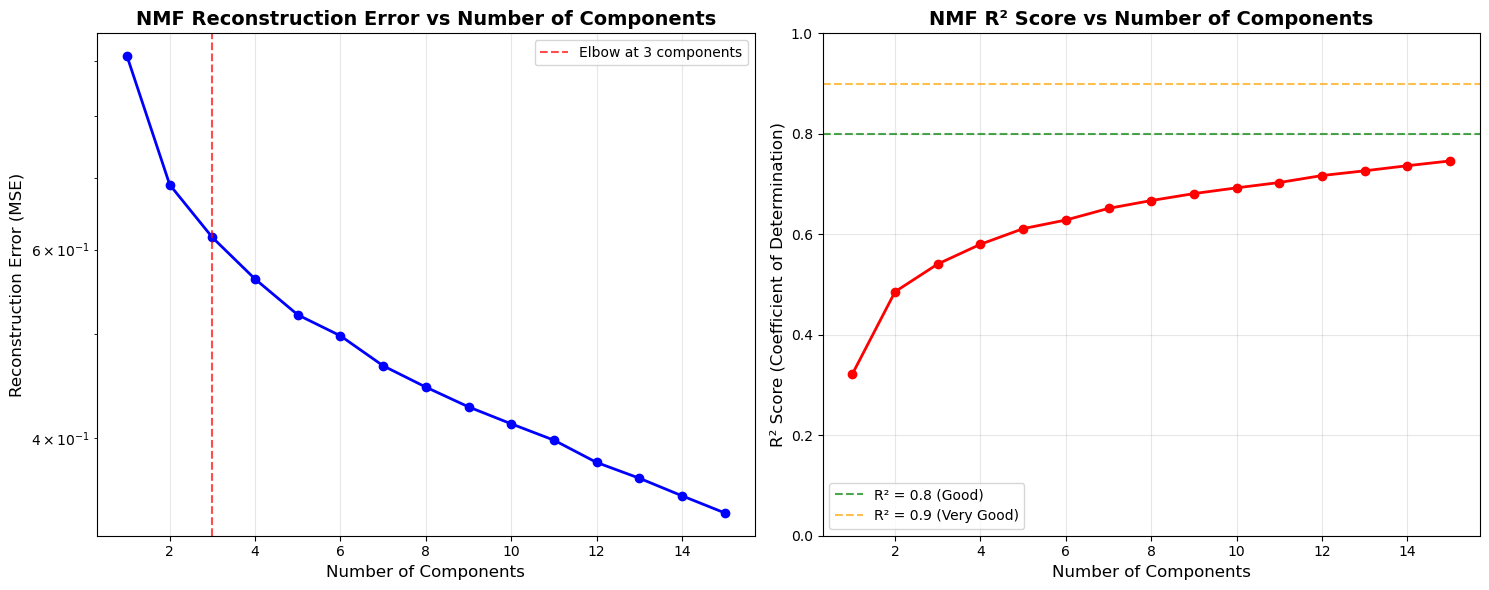


NMF COMPONENT SELECTION SUMMARY
Matrix dimensions: 30912 feature-time combinations × 60 conditions
Features: ['velocity magnitude [m/s]_mean', 'vorticity [1/s]_mean', 'divergence [1/s]_mean', 'correlation length [m]_mean', 'work [J]_mean', 'velocity magnitude [m/s]_dt', 'correlation length [m]_dt']
Tested component range: 1 to 15

Optimal components by minimum reconstruction error: 15
Components for R² ≥ 0.8 (Good fit): 15
Components for R² ≥ 0.9 (Very good fit): 15
Elbow point (maximum curvature): 3 components

Final recommendation: Use 15 components for optimal reconstruction


In [104]:
# Visualize reconstruction error and explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot reconstruction error (MSE)
ax1.plot(n_components_range, reconstruction_errors, 'bo-', linewidth=2, markersize=6)
ax1.set_xlabel('Number of Components', fontsize=12)
ax1.set_ylabel('Reconstruction Error (MSE)', fontsize=12)
ax1.set_title('NMF Reconstruction Error vs Number of Components', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Add elbow detection
if len(reconstruction_errors) > 2:
    # Calculate second derivative to find elbow
    second_deriv = np.diff(reconstruction_errors, 2)
    if len(second_deriv) > 0:
        elbow_idx = np.argmax(second_deriv) + 2  # +2 because of double diff
        elbow_components = list(n_components_range)[elbow_idx]
        ax1.axvline(x=elbow_components, color='red', linestyle='--', alpha=0.7, 
                   label=f'Elbow at {elbow_components} components')
        ax1.legend()

# Plot R² score (coefficient of determination)
ax2.plot(n_components_range, explained_variance_ratios, 'ro-', linewidth=2, markersize=6)
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('R² Score (Coefficient of Determination)', fontsize=12)
ax2.set_title('NMF R² Score vs Number of Components', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

# Add R² reference lines
ax2.axhline(y=0.8, color='green', linestyle='--', alpha=0.7, label='R² = 0.8 (Good)')
ax2.axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='R² = 0.9 (Very Good)')
ax2.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("NMF COMPONENT SELECTION SUMMARY")
print("="*60)

print(f"Matrix dimensions: {multi_feature_matrix.shape[0]} feature-time combinations × {multi_feature_matrix.shape[1]} conditions")
print(f"Features: {feature_names}")
print(f"Tested component range: {min(n_components_range)} to {max(n_components_range)}")

# Find optimal number of components using different criteria
min_error_idx = np.argmin(reconstruction_errors)
min_error_components = list(n_components_range)[min_error_idx]

# Find components needed for R² = 0.8 and R² = 0.9
r2_80_idx = next((i for i, v in enumerate(explained_variance_ratios) if v >= 0.8), len(explained_variance_ratios)-1)
r2_90_idx = next((i for i, v in enumerate(explained_variance_ratios) if v >= 0.9), len(explained_variance_ratios)-1)

r2_80_components = list(n_components_range)[r2_80_idx]
r2_90_components = list(n_components_range)[r2_90_idx]

print(f"\nOptimal components by minimum reconstruction error: {min_error_components}")
print(f"Components for R² ≥ 0.8 (Good fit): {r2_80_components}")
print(f"Components for R² ≥ 0.9 (Very good fit): {r2_90_components}")

# Show the elbow point if detected
if len(reconstruction_errors) > 2:
    second_deriv = np.diff(reconstruction_errors, 2)
    if len(second_deriv) > 0:
        elbow_idx = np.argmax(second_deriv) + 2
        elbow_components = list(n_components_range)[elbow_idx]
        print(f"Elbow point (maximum curvature): {elbow_components} components")

print(f"\nFinal recommendation: Use {min_error_components} components for optimal reconstruction")


In [105]:
# Perform NMF with automatically selected components (no hardcoding)

# Choose component count from prior diagnostics
selection_candidates = {
    'min_error': min_error_components,
    'elbow': elbow_components if 'elbow_components' in locals() else None,
    'r2_90': r2_90_components,
    'r2_80': r2_80_components,
}
selection_order = ['elbow', 'min_error', 'r2_90', 'r2_80']
optimal_components = next(selection_candidates[k] for k in selection_order if selection_candidates.get(k) is not None)
print(f"Performing NMF with {optimal_components} components (auto-selected)")

nmf_optimal = NMF(n_components=optimal_components, random_state=42, max_iter=5000)
W_optimal = nmf_optimal.fit_transform(multi_feature_matrix)
H_optimal = nmf_optimal.components_

print("NMF factorization complete!")
print(f"W matrix shape (feature-time × components): {W_optimal.shape}")
print(f"H matrix shape (components × conditions): {H_optimal.shape}")

# Calculate final reconstruction error
reconstructed_optimal = W_optimal @ H_optimal
final_mse = mean_squared_error(multi_feature_matrix.flatten(), reconstructed_optimal.flatten())

print(f"Final reconstruction MSE: {final_mse:.2e}")

# Store results for further analysis
nmf_results = {
    'n_components': optimal_components,
    'W': W_optimal,
    'H': H_optimal,
    'reconstruction_error': final_mse,
    'model': nmf_optimal,
    'time_index': time_index,
    'condition_columns': condition_columns,
    'feature_names': feature_names,
    'feature_labels': feature_labels
}

print("Multi-feature NMF analysis complete! Results stored in 'nmf_results' dictionary.")


Performing NMF with 3 components (auto-selected)
NMF factorization complete!
W matrix shape (feature-time × components): (30912, 3)
H matrix shape (components × conditions): (3, 60)
Final reconstruction MSE: 6.16e-01
Multi-feature NMF analysis complete! Results stored in 'nmf_results' dictionary.


Visualizing NMF components (multi-feature patterns)...


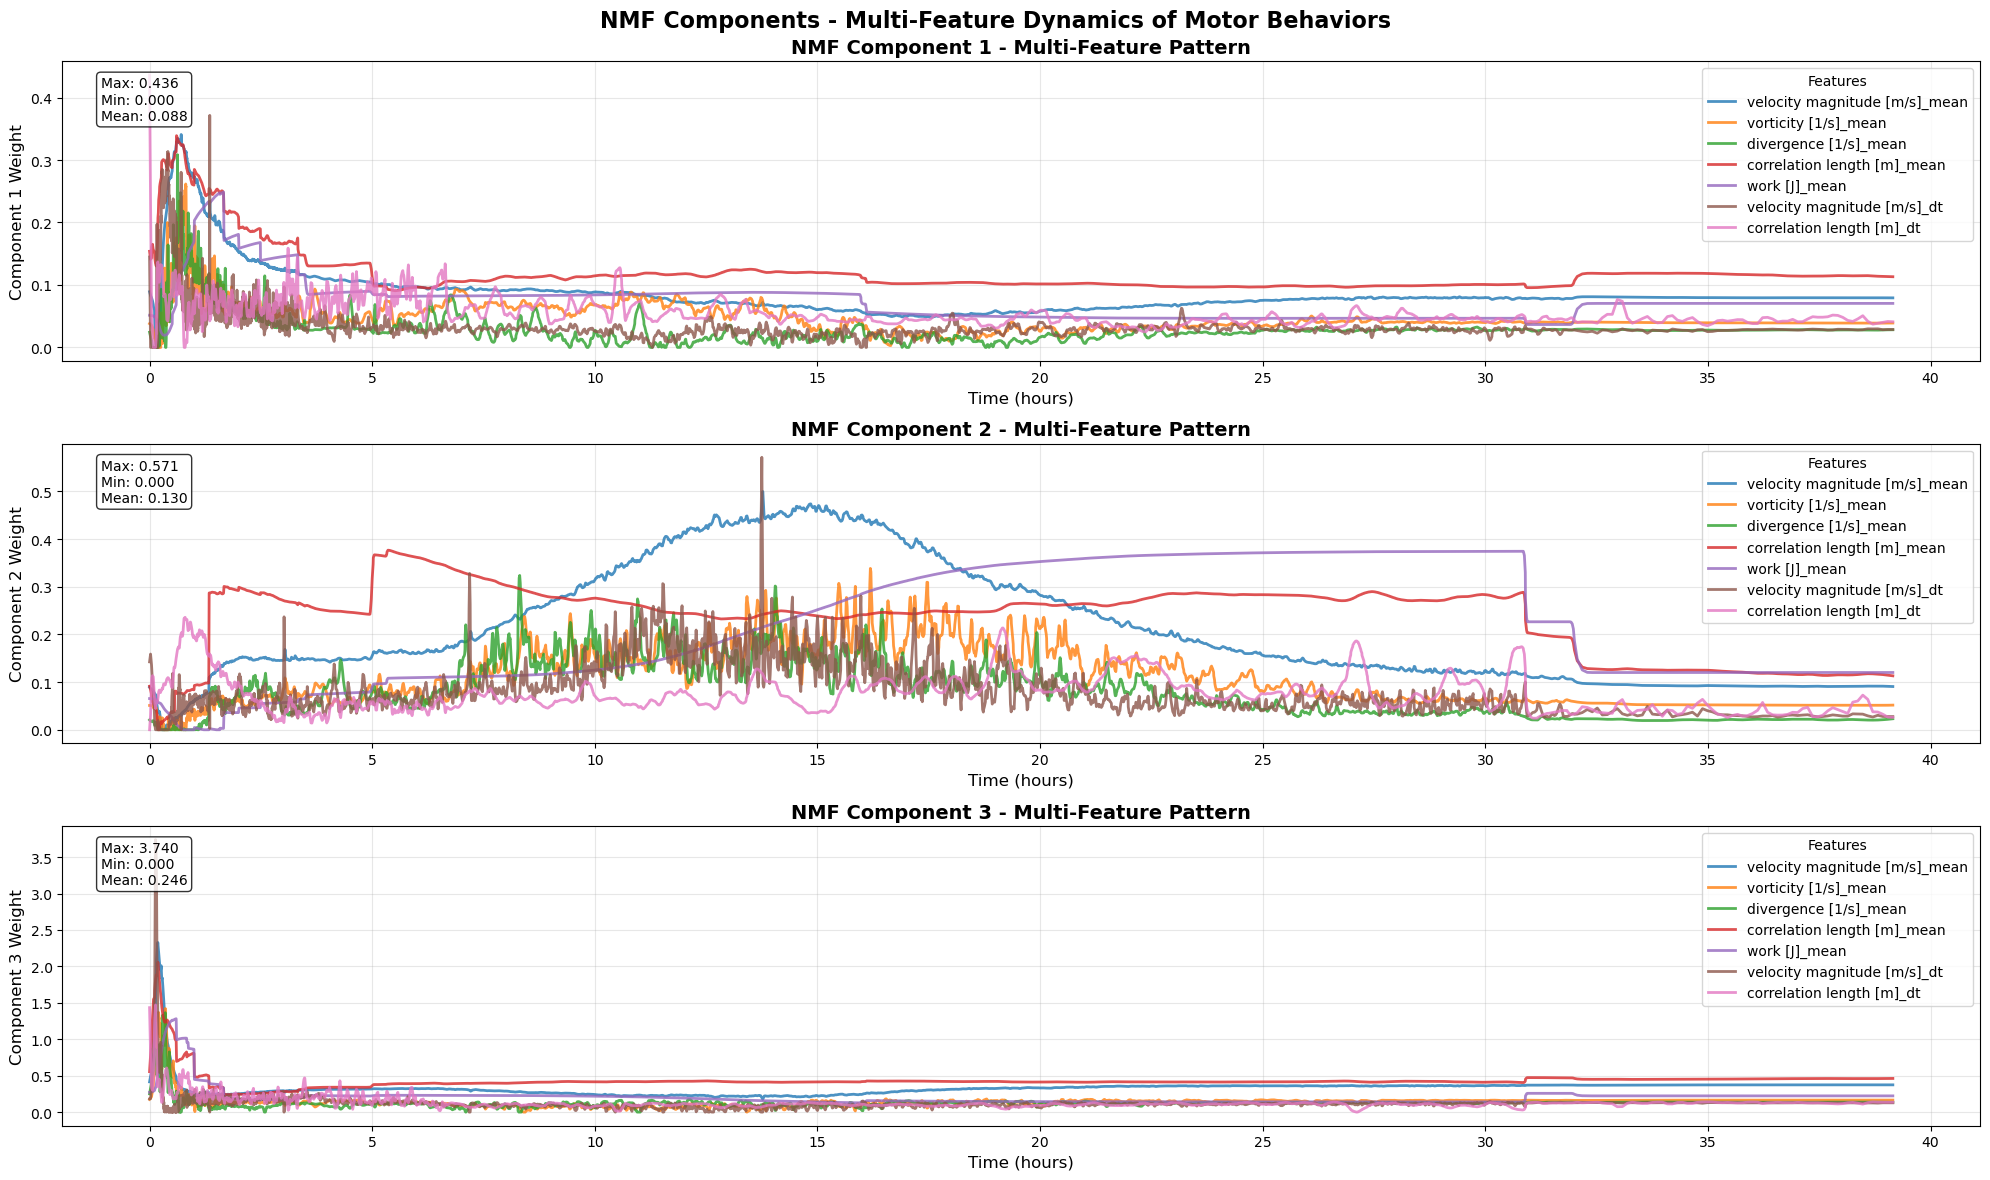

Multi-feature component visualization complete!


In [106]:
# Visualize NMF Components (W matrix - multi-feature patterns) dynamically
print("Visualizing NMF components (multi-feature patterns)...")

n_components = nmf_results['n_components']
fig, axes = plt.subplots(n_components, 1, figsize=(20, 4 * n_components))
if n_components == 1:
    axes = [axes]

# Create time axis for each feature
time_hours = nmf_results['time_index'] / 3600

for i in range(n_components):
    ax = axes[i]
    
    # Plot each feature separately for this component
    start_idx = 0
    for j, feature in enumerate(nmf_results['feature_names']):
        end_idx = start_idx + len(time_hours)
        feature_values = nmf_results['W'][start_idx:end_idx, i]
        
        ax.plot(time_hours, feature_values, linewidth=2, 
               label=feature, color=f'C{j}', alpha=0.8)
        start_idx = end_idx
    
    ax.set_title(f'NMF Component {i+1} - Multi-Feature Pattern', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (hours)', fontsize=12)
    ax.set_ylabel(f'Component {i+1} Weight', fontsize=12)
    ax.legend(title='Features', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add some statistics
    component_values = nmf_results['W'][:, i]
    ax.text(0.02, 0.95, f'Max: {component_values.max():.3f}\nMin: {component_values.min():.3f}\nMean: {component_values.mean():.3f}', 
            transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('NMF Components - Multi-Feature Dynamics of Motor Behaviors', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Multi-feature component visualization complete!")


Visualizing NMF component contributions across motor conditions...


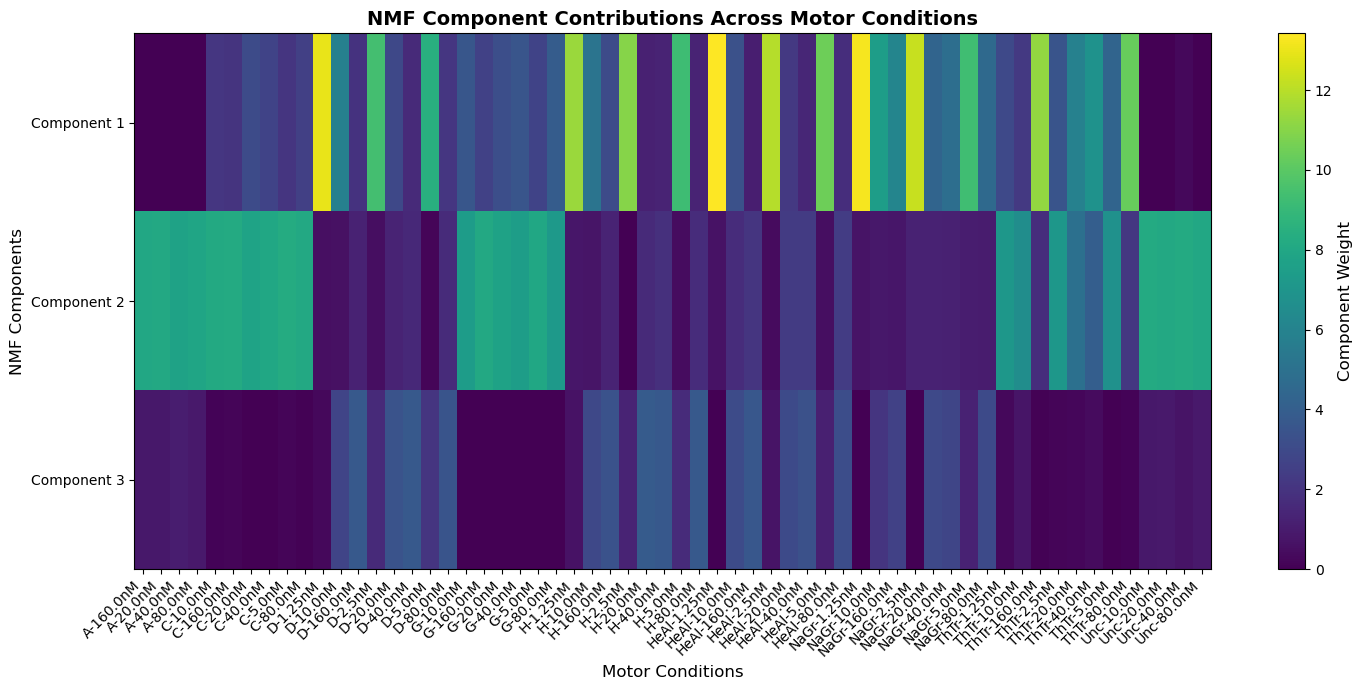


Component contribution statistics:
Component 1:
  Mean contribution: 4.643
  Max contribution: 13.420
  Min contribution: 0.000
  Std deviation: 3.978

Component 2:
  Mean contribution: 3.936
  Max contribution: 8.232
  Min contribution: 0.000
  Std deviation: 3.230

Component 3:
  Mean contribution: 1.420
  Max contribution: 3.839
  Min contribution: 0.000
  Std deviation: 1.378



In [107]:
# Visualize NMF Component Contributions (H matrix - condition patterns)
print("Visualizing NMF component contributions across motor conditions...")

n_components = nmf_results['n_components']

# Create a heatmap of component contributions
fig, ax = plt.subplots(figsize=(15, 4 + n_components))

# Create heatmap
im = ax.imshow(nmf_results['H'], cmap='viridis', aspect='auto')

# Set labels
ax.set_xlabel('Motor Conditions', fontsize=12)
ax.set_ylabel('NMF Components', fontsize=12)
ax.set_title('NMF Component Contributions Across Motor Conditions', fontsize=14, fontweight='bold')

# Set tick labels
ax.set_xticks(range(len(nmf_results['condition_columns'])))
ax.set_xticklabels(nmf_results['condition_columns'], rotation=45, ha='right')
ax.set_yticks(range(n_components))
ax.set_yticklabels([f'Component {i+1}' for i in range(n_components)])

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Component Weight', fontsize=12)

plt.tight_layout()
plt.show()

# Print component contribution statistics
print("\nComponent contribution statistics:")
for i in range(n_components):
    component_contributions = nmf_results['H'][i, :]
    print(f"Component {i+1}:")
    print(f"  Mean contribution: {component_contributions.mean():.3f}")
    print(f"  Max contribution: {component_contributions.max():.3f}")
    print(f"  Min contribution: {component_contributions.min():.3f}")
    print(f"  Std deviation: {component_contributions.std():.3f}")
    print()


In [108]:
# Identify dominant components for each motor condition
print("Identifying dominant NMF components for each motor condition...")

n_components = nmf_results['n_components']
component_names = [f'Component {i+1}' for i in range(n_components)]

# Find the dominant component for each condition
dominant_components = np.argmax(nmf_results['H'], axis=0)

# Create a summary dataframe with dynamic component weights
component_weight_cols = {f'Component_{i+1}_Weight': nmf_results['H'][i, :] for i in range(n_components)}

condition_summary = pd.DataFrame({
    'Condition': nmf_results['condition_columns'],
    'Dominant_Component': [component_names[i] for i in dominant_components],
    **component_weight_cols
})

# Ensure Condition column is string type
condition_summary['Condition'] = condition_summary['Condition'].astype(str)

# Add protein and DNA concentration info with error handling
def parse_condition(condition_str):
    """Parse condition string to extract protein and DNA concentration"""
    try:
        parts = str(condition_str).split('-')
        if len(parts) >= 2:
            protein = parts[0]
            dna_part = parts[1].replace('nM', '').replace('n', '')
            # Handle cases where DNA might be in different formats
            dna_clean = dna_part.replace('p', '.').replace('_', '')
            try:
                dna_value = float(dna_clean)
                return protein, dna_value
            except ValueError:
                return protein, np.nan
        else:
            return condition_str, np.nan
    except:
        return condition_str, np.nan

# Apply parsing function
parsed_data = condition_summary['Condition'].apply(parse_condition)
condition_summary['Protein'] = [x[0] for x in parsed_data]
condition_summary['DNA_nM'] = [x[1] for x in parsed_data]

# Debug: Check the condition strings
print("Debug: Sample condition strings:")
print("First 5 conditions:", nmf_results['condition_columns'][:5])
print("Data types:", [type(x) for x in nmf_results['condition_columns'][:5]])

print("\nCondition summary (first 10 rows):")
print(condition_summary.head(10))

# Count how many conditions are dominated by each component
component_counts = pd.Series(dominant_components).value_counts().sort_index()
print(f"\nComponent dominance counts:")
for i, count in component_counts.items():
    print(f"  {component_names[i]}: {count} conditions")

# Group by protein to see patterns
print(f"\nComponent patterns by protein:")
protein_patterns = condition_summary.groupby('Protein')['Dominant_Component'].value_counts().unstack(fill_value=0)
print(protein_patterns)


Identifying dominant NMF components for each motor condition...
Debug: Sample condition strings:
First 5 conditions: ['A-160.0nM', 'A-20.0nM', 'A-40.0nM', 'A-80.0nM', 'C-10.0nM']
Data types: [<class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>]

Condition summary (first 10 rows):
   Condition Dominant_Component  Component_1_Weight  Component_2_Weight  \
0  A-160.0nM        Component 2            0.000000            8.021971   
1   A-20.0nM        Component 2            0.000000            8.113490   
2   A-40.0nM        Component 2            0.000000            7.726115   
3   A-80.0nM        Component 2            0.000000            7.883676   
4   C-10.0nM        Component 2            2.149283            8.157163   
5  C-160.0nM        Component 2            2.043532            8.215921   
6   C-20.0nM        Component 2            3.075979            7.782601   
7   C-40.0nM        Component 2            2.722827            7.976843   
8    C-5.0nM        Co

Performing silhouette analysis for cluster quality assessment...
Calculating silhouette scores...
Overall Silhouette Score: 0.566
Cluster 1 Average Silhouette Score: 0.272
Cluster 2 Average Silhouette Score: 0.720
Cluster 3 Average Silhouette Score: 0.847


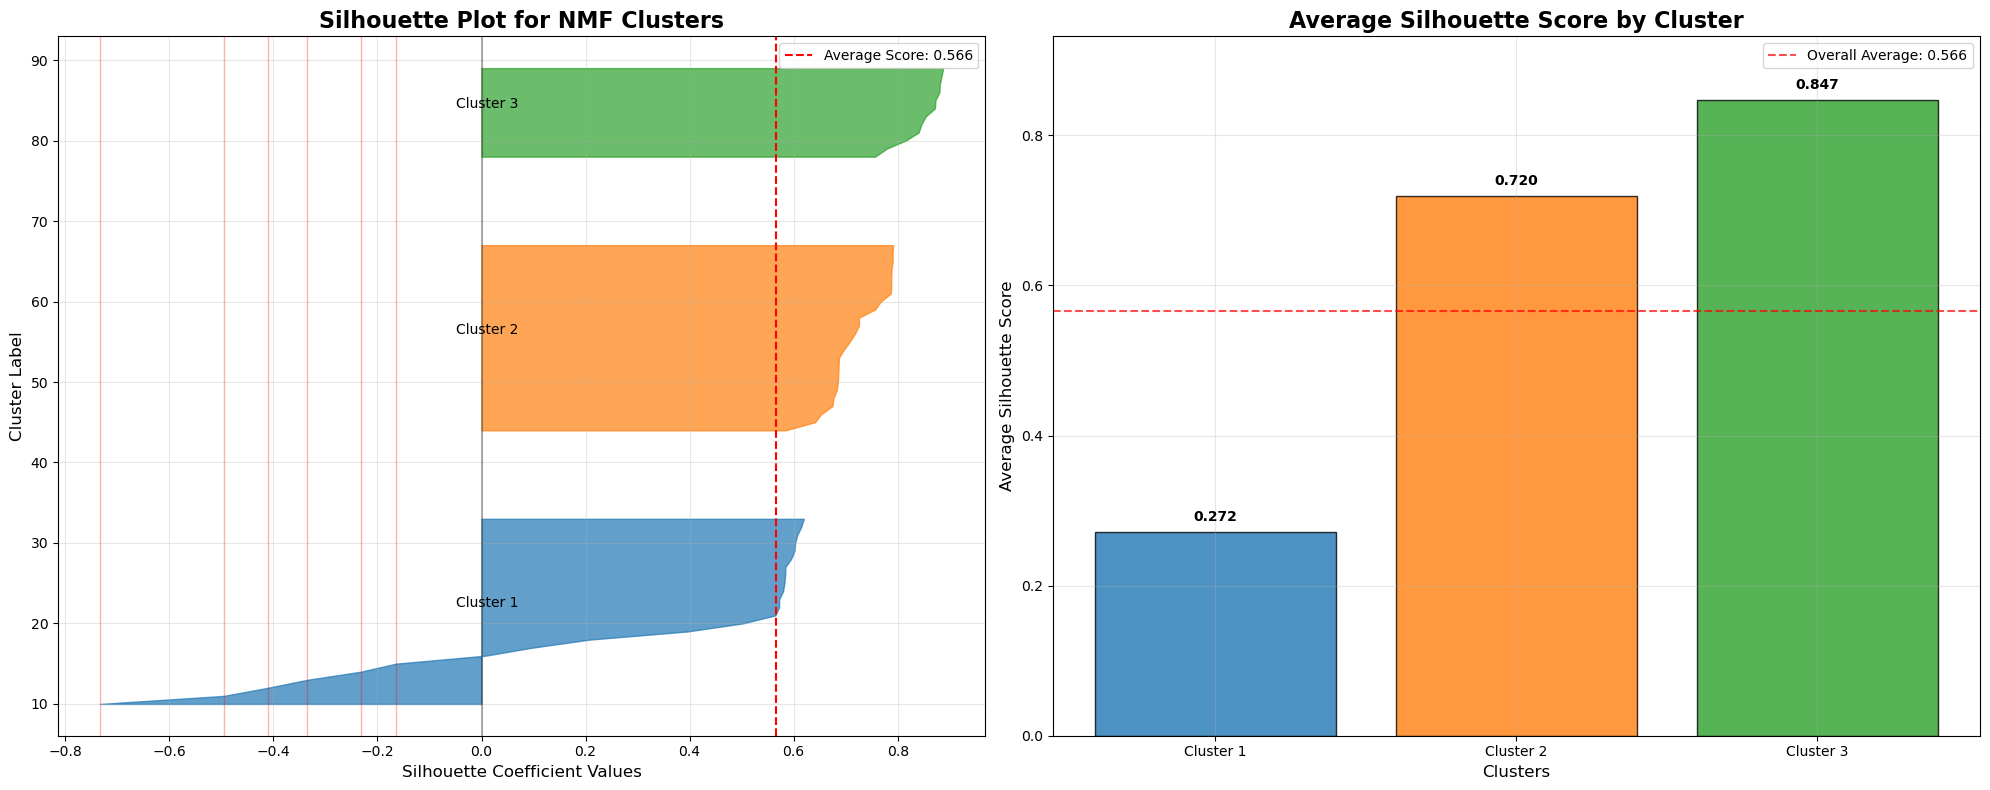


SILHOUETTE ANALYSIS INTERPRETATION
Overall Silhouette Score: 0.566
✅ GOOD clustering - Reasonable structure

Cluster-specific scores:
  Cluster 1: 0.272 (Fair)
  Cluster 2: 0.720 (Excellent)
  Cluster 3: 0.847 (Excellent)

Silhouette Score Range: [-1, 1]
  • 1: Perfect clustering
  • 0: Overlapping clusters
  • -1: Incorrect clustering

ANALYSIS OF NEGATIVE SILHOUETTE SCORES
Number of samples with negative silhouette scores: 6 out of 60 (10.0%)

Samples with negative silhouette scores:
  • H-10.0nM: Cluster 1, Score: -0.232
  • HeAl-10.0nM: Cluster 1, Score: -0.733
  • NaGr-20.0nM: Cluster 1, Score: -0.495
  • NaGr-40.0nM: Cluster 1, Score: -0.335
  • NaGr-80.0nM: Cluster 1, Score: -0.411
  • ThTr-20.0nM: Cluster 1, Score: -0.165

Interpretation of negative scores:
  • These samples are closer to a DIFFERENT cluster than their assigned one
  • They may be 'borderline' cases between clusters
  • Consider if these samples should be reassigned or represent intermediate states
  • This is

In [109]:
# Add Silhouette Analysis for Quantitative Cluster Evaluation
print("Performing silhouette analysis for cluster quality assessment...")

from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm
#define itertools
import itertools

# Calculate silhouette scores
print("Calculating silhouette scores...")

# Use the NMF component weights as features for silhouette analysis
H_matrix = nmf_results['H'].T  # Transpose to get (conditions × components)
cluster_labels = dominant_components

# Get the number of components dynamically
n_components = nmf_results['n_components']
n_clusters = len(np.unique(cluster_labels))

# Define consistent colors for clusters dynamically
base_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
cluster_colors = list(itertools.islice(itertools.cycle(base_colors), n_clusters))
cluster_names = [f'Cluster {i+1}' for i in range(n_clusters)]

# Calculate overall silhouette score
silhouette_avg = silhouette_score(H_matrix, cluster_labels)
print(f"Overall Silhouette Score: {silhouette_avg:.3f}")

# Calculate silhouette scores for each sample
silhouette_values = silhouette_samples(H_matrix, cluster_labels)

# Calculate silhouette scores for each cluster
cluster_silhouette_scores = {}
for i in range(n_clusters):
    cluster_mask = cluster_labels == i
    cluster_silhouette_avg = silhouette_values[cluster_mask].mean()
    cluster_silhouette_scores[f'Cluster {i+1}'] = cluster_silhouette_avg
    print(f"Cluster {i+1} Average Silhouette Score: {cluster_silhouette_avg:.3f}")

# Create silhouette plot with enhanced analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Silhouette plot
y_lower = 10
for i in range(n_clusters):
    # Aggregate the silhouette scores for samples belonging to cluster i
    cluster_silhouette_values = silhouette_values[cluster_labels == i]
    cluster_silhouette_values.sort()
    
    size_cluster_i = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = cluster_colors[i]
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    
    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, f'Cluster {i+1}')
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_xlabel('Silhouette Coefficient Values', fontsize=12)
ax1.set_ylabel('Cluster Label', fontsize=12)
ax1.set_title('Silhouette Plot for NMF Clusters', fontsize=16, fontweight='bold')
ax1.axvline(x=silhouette_avg, color="red", linestyle="--", 
           label=f'Average Score: {silhouette_avg:.3f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add vertical line for average silhouette score
ax1.axvline(x=0, color="black", linestyle="-", alpha=0.3)

# Highlight negative scores with different styling
for i in range(n_clusters):
    cluster_mask = cluster_labels == i
    cluster_silhouette_values = silhouette_values[cluster_mask]
    cluster_silhouette_values.sort()
    
    negative_mask = cluster_silhouette_values < 0
    if negative_mask.any():
        negative_values = cluster_silhouette_values[negative_mask]
        for val in negative_values:
            y_pos = np.where(cluster_silhouette_values == val)[0][0]
            ax1.axvline(x=val, ymin=0, ymax=1, color='red', alpha=0.3, linewidth=1)

# Bar plot of silhouette scores by cluster
clusters = list(cluster_silhouette_scores.keys())
scores = list(cluster_silhouette_scores.values())
colors_bar = cluster_colors[:len(clusters)]

bars = ax2.bar(clusters, scores, color=colors_bar, alpha=0.8, edgecolor='black')
ax2.set_title('Average Silhouette Score by Cluster', fontsize=16, fontweight='bold')
ax2.set_xlabel('Clusters', fontsize=12)
ax2.set_ylabel('Average Silhouette Score', fontsize=12)
ax2.set_ylim(0, max(scores) * 1.1 if len(scores) else 1)

# Add score labels on bars
for i, (bar, score) in enumerate(zip(bars, scores)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# Add horizontal line for overall average
ax2.axhline(y=silhouette_avg, color='red', linestyle='--', alpha=0.7,
           label=f'Overall Average: {silhouette_avg:.3f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print interpretation
print(f"\n" + "="*60)
print("SILHOUETTE ANALYSIS INTERPRETATION")
print("="*60)
print(f"Overall Silhouette Score: {silhouette_avg:.3f}")

if silhouette_avg > 0.7:
    print("✅ EXCELLENT clustering - Strong, well-separated clusters")
elif silhouette_avg > 0.5:
    print("✅ GOOD clustering - Reasonable structure")
elif silhouette_avg > 0.25:
    print("⚠️  FAIR clustering - Weak but potentially meaningful structure")
else:
    print("❌ POOR clustering - No substantial structure")

print(f"\nCluster-specific scores:")
for cluster, score in cluster_silhouette_scores.items():
    if score > 0.7:
        quality = "Excellent"
    elif score > 0.5:
        quality = "Good"
    elif score > 0.25:
        quality = "Fair"
    else:
        quality = "Poor"
    print(f"  {cluster}: {score:.3f} ({quality})")

print(f"\nSilhouette Score Range: [-1, 1]")
print(f"  • 1: Perfect clustering")
print(f"  • 0: Overlapping clusters")
print(f"  • -1: Incorrect clustering")

# Analyze samples with negative silhouette scores
print(f"\n" + "="*60)
print("ANALYSIS OF NEGATIVE SILHOUETTE SCORES")
print("="*60)

negative_samples = silhouette_values < 0
n_negative = negative_samples.sum()
print(f"Number of samples with negative silhouette scores: {n_negative} out of {len(silhouette_values)} ({n_negative/len(silhouette_values)*100:.1f}%)")

if n_negative > 0:
    print(f"\nSamples with negative silhouette scores:")
    negative_indices = np.where(negative_samples)[0]
    for idx in negative_indices:
        condition_name = condition_summary.iloc[idx]['Condition']
        cluster_assigned = cluster_labels[idx]
        silhouette_val = silhouette_values[idx]
        print(f"  • {condition_name}: Cluster {cluster_assigned + 1}, Score: {silhouette_val:.3f}")
    
    print(f"\nInterpretation of negative scores:")
    print(f"  • These samples are closer to a DIFFERENT cluster than their assigned one")
    print(f"  • They may be 'borderline' cases between clusters")
    print(f"  • Consider if these samples should be reassigned or represent intermediate states")
    print(f"  • This is normal in biological data where boundaries can be fuzzy")

# Analyze cluster separation
print(f"\n" + "="*60)
print("CLUSTER SEPARATION ANALYSIS")
print("="*60)

for i in range(n_clusters):
    cluster_mask = cluster_labels == i
    cluster_silhouette_vals = silhouette_values[cluster_mask]
    n_negative_in_cluster = (cluster_silhouette_vals < 0).sum()
    n_total_in_cluster = len(cluster_silhouette_vals)
    
    print(f"Cluster {i+1}:")
    print(f"  • Total samples: {n_total_in_cluster}")
    print(f"  • Negative scores: {n_negative_in_cluster} ({n_negative_in_cluster/n_total_in_cluster*100:.1f}%)")
    print(f"  • Average score: {cluster_silhouette_vals.mean():.3f}")
    print(f"  • Score range: [{cluster_silhouette_vals.min():.3f}, {cluster_silhouette_vals.max():.3f}]")


Creating visualizations of NMF component patterns...


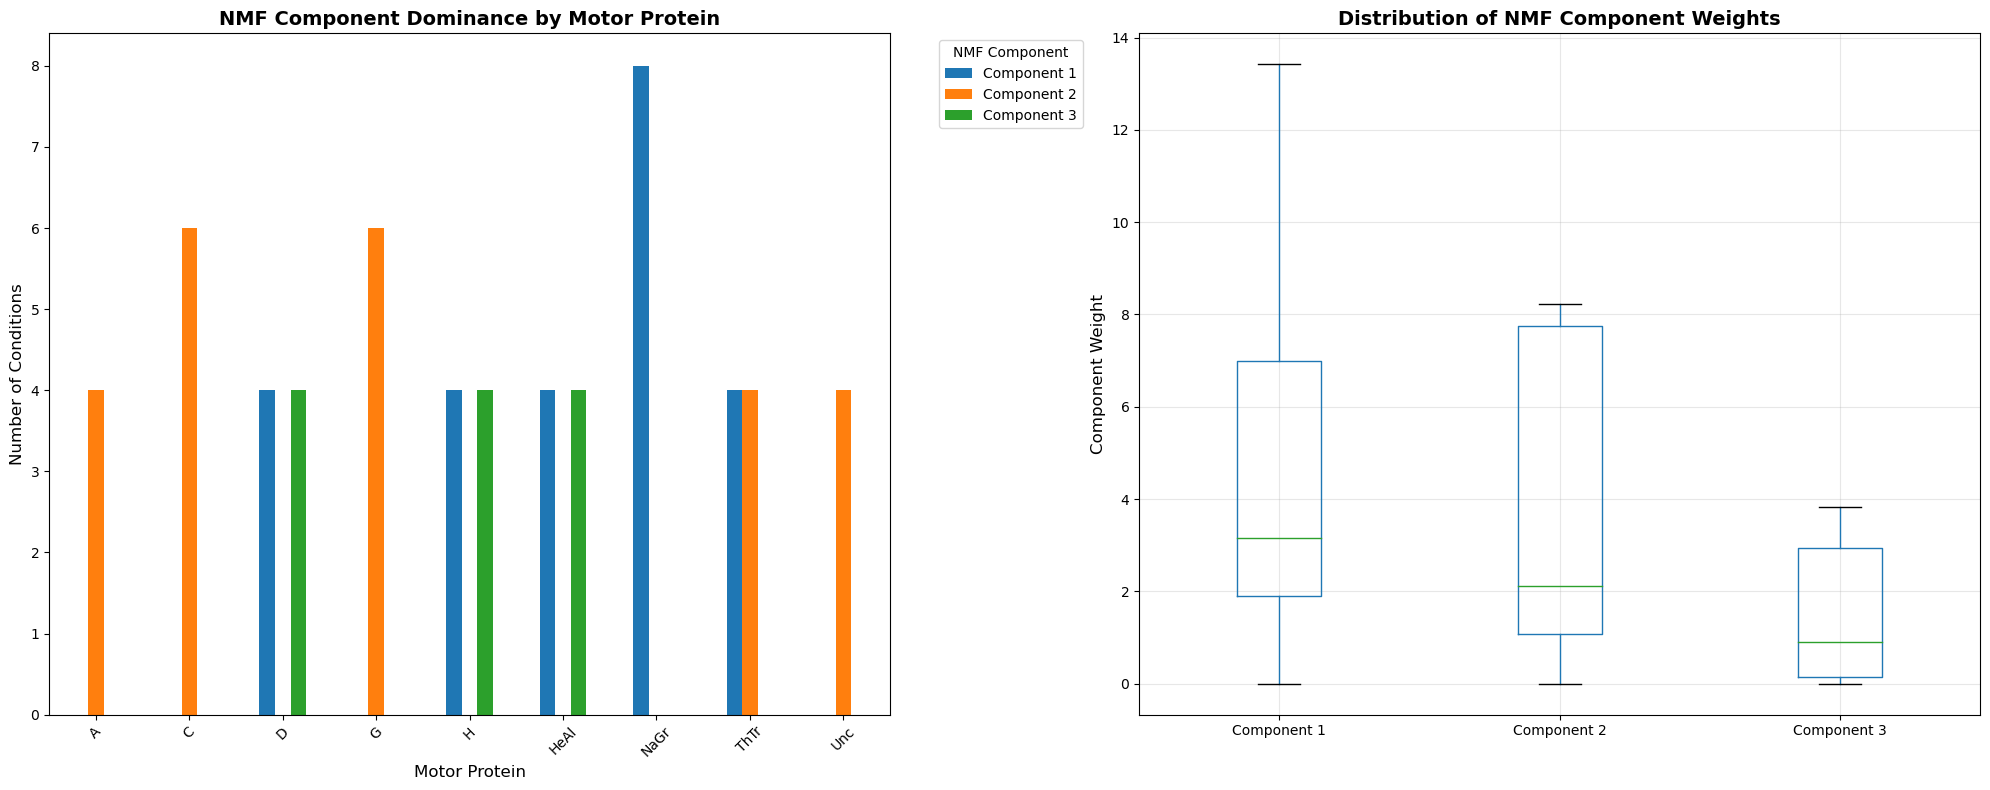

Component pattern visualization complete!


In [110]:
# Visualize component patterns by protein
print("Creating visualizations of NMF component patterns...")

n_components = nmf_results['n_components']
component_names = [f'Component {i+1}' for i in range(n_components)]

# Create a grouped bar plot showing component dominance by protein
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Component dominance by protein
protein_patterns.plot(kind='bar', ax=ax1, color=[f'C{i}' for i in range(n_components)])
ax1.set_title('NMF Component Dominance by Motor Protein', fontsize=14, fontweight='bold')
ax1.set_xlabel('Motor Protein', fontsize=12)
ax1.set_ylabel('Number of Conditions', fontsize=12)
ax1.legend(title='NMF Component', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Component weights distribution
component_weights = pd.DataFrame({
    name: nmf_results['H'][idx, :] for idx, name in enumerate(component_names)
})

component_weights.boxplot(ax=ax2)
ax2.set_title('Distribution of NMF Component Weights', fontsize=14, fontweight='bold')
ax2.set_ylabel('Component Weight', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Component pattern visualization complete!")


## Bootstrapping Analysis & Feature Separation

### Is Bootstrapping Needed?

**Short answer: Not strictly necessary, but highly recommended for robust results.**

**Why bootstrapping helps:**
- NMF can be sensitive to initialization and data variations
- Bootstrapping assesses the **stability** of your components across resamples
- Provides confidence intervals for feature importance rankings
- Validates that your findings are robust, not artifacts of a single run

**Current approach:** Your notebook uses `random_state=42`, which makes results reproducible but doesn't assess stability.

**Recommendation:** If you're publishing or making important decisions, bootstrapping is valuable. For exploratory analysis, it's optional but good practice.

In [111]:
# OPTIONAL: Bootstrapping Analysis for NMF Stability
# This assesses how stable your NMF components are across resamples

from sklearn.utils import resample
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

def bootstrap_nmf(data, n_components, n_bootstrap=100, random_state=42):
    """
    Perform bootstrapped NMF to assess component stability.
    
    Returns:
    - component_stabilities: correlation of components across bootstrap runs
    - feature_importances_bootstrap: feature importance across all runs
    """
    np.random.seed(random_state)
    
    n_samples, n_features = data.shape
    component_stabilities = []
    feature_importances_bootstrap = []
    
    # Reference run with full data
    nmf_ref = NMF(n_components=n_components, random_state=42, max_iter=1000)
    W_ref = nmf_ref.fit_transform(data)
    H_ref = nmf_ref.components_
    
    print(f"Running {n_bootstrap} bootstrap iterations...")
    for i in range(n_bootstrap):
        if (i + 1) % 20 == 0:
            print(f"  Completed {i + 1}/{n_bootstrap} iterations...")
        
        # Resample with replacement
        bootstrap_indices = resample(np.arange(n_samples), n_samples=n_samples, random_state=i)
        data_bootstrap = data[bootstrap_indices, :]
        
        # Fit NMF on bootstrap sample
        nmf_bs = NMF(n_components=n_components, random_state=i, max_iter=1000)
        W_bs = nmf_bs.fit_transform(data_bootstrap)
        H_bs = nmf_bs.components_
        
        # Calculate correlation between reference and bootstrap components
        # (need to find best matching components)
        correlations = np.abs(np.corrcoef(H_ref.flatten(), H_bs.flatten()))[0, 1]
        component_stabilities.append(correlations)
        
        # Calculate feature importance (variance in W matrix per feature)
        # Reshape W to separate features and time points
        n_timepoints = len(time_index)
        n_features_original = len(feature_names)
        
        if W_bs.shape[0] == n_timepoints * n_features_original:
            W_reshaped = W_bs.reshape(n_features_original, n_timepoints, n_components)
            feature_importance = np.var(W_reshaped, axis=1).sum(axis=1)  # Sum across components
            feature_importances_bootstrap.append(feature_importance)
    
    return {
        'component_stabilities': component_stabilities,
        'feature_importances': np.array(feature_importances_bootstrap),
        'mean_stability': np.mean(component_stabilities),
        'std_stability': np.std(component_stabilities)
    }

# Uncomment to run bootstrapping (takes a few minutes)
bootstrap_results = bootstrap_nmf(multi_feature_matrix, optimal_components, n_bootstrap=5)
print(f"\nBootstrap Results:")
print(f"  Mean component stability: {bootstrap_results['mean_stability']:.3f} ± {bootstrap_results['std_stability']:.3f}")
print(f"  Stability > 0.8: {'✓ Stable' if bootstrap_results['mean_stability'] > 0.8 else '⚠ Moderate stability'}")

Running 5 bootstrap iterations...

Bootstrap Results:
  Mean component stability: 0.850 ± 0.298
  Stability > 0.8: ✓ Stable


### Which PIV Features Provide the Most Separation?

This analysis calculates how well each PIV feature separates different motor conditions by:
1. **Component loadings**: How much each feature contributes to each NMF component
2. **Between-group variance**: How well features distinguish between conditions
3. **Separation score**: A combined metric ranking features by their discriminative power

In [112]:
# Feature Separation Analysis
# Identify which PIV features provide the most separation between motor conditions

print("=" * 60)
print("FEATURE SEPARATION ANALYSIS")
print("=" * 60)

# Get NMF results
W = nmf_results['W']  # Shape: (n_feature_timepoints, n_components)
H = nmf_results['H']  # Shape: (n_components, n_conditions)
n_components = nmf_results['n_components']
feature_names = nmf_results['feature_names']
time_index = nmf_results['time_index']
condition_columns = nmf_results['condition_columns']

# Reshape W matrix to separate features and time points
n_timepoints = len(time_index)
n_features = len(feature_names)

# W is stacked as: [feature1_t1, feature1_t2, ..., feature1_tN, feature2_t1, ...]
# Reshape to (n_features, n_timepoints, n_components)
W_reshaped = W.reshape(n_features, n_timepoints, n_components)

# Method 1: Feature importance based on variance in component loadings
print("\n1. FEATURE IMPORTANCE (Variance in Component Loadings)")
print("-" * 60)

feature_importance_scores = {}
for feat_idx, feat_name in enumerate(feature_names):
    # Get component loadings for this feature across all time points
    feature_loadings = W_reshaped[feat_idx, :, :]  # Shape: (n_timepoints, n_components)
    
    # Calculate total variance across components and time
    total_variance = np.var(feature_loadings)
    
    # Calculate variance per component (how much this feature contributes to each component)
    variance_per_component = np.var(feature_loadings, axis=0)
    max_component_variance = np.max(variance_per_component)
    
    feature_importance_scores[feat_name] = {
        'total_variance': total_variance,
        'max_component_variance': max_component_variance,
        'mean_variance': np.mean(variance_per_component),
        'variance_per_component': variance_per_component
    }
    
    print(f"  {feat_name}:")
    print(f"    Total variance: {total_variance:.4f}")
    print(f"    Max component variance: {max_component_variance:.4f}")

# Method 2: Separation score based on H matrix (how well features distinguish conditions)
print("\n2. CONDITION SEPARATION SCORE")
print("-" * 60)

# For each feature, calculate how well it separates conditions
# by looking at the variance in H matrix contributions
feature_separation_scores = {}

for feat_idx, feat_name in enumerate(feature_names):
    # Get the portion of H that corresponds to this feature
    # Since H is (components × conditions), we need to weight by feature importance
    feature_loadings = W_reshaped[feat_idx, :, :]
    feature_weights = np.mean(np.abs(feature_loadings), axis=0)  # Average absolute loading per component
    
    # Weight H matrix by this feature's contribution
    weighted_H = H * feature_weights[:, np.newaxis]  # Shape: (n_components, n_conditions)
    
    # Calculate between-condition variance (higher = better separation)
    condition_variance = np.var(weighted_H, axis=1).sum()
    
    # Calculate separation as the difference between max and min contributions per condition
    condition_range = np.ptp(weighted_H, axis=0).mean()  # Peak-to-peak per condition, averaged
    
    feature_separation_scores[feat_name] = {
        'condition_variance': condition_variance,
        'condition_range': condition_range,
        'separation_score': condition_variance * condition_range  # Combined metric
    }
    
    print(f"  {feat_name}:")
    print(f"    Condition variance: {condition_variance:.4f}")
    print(f"    Condition range: {condition_range:.4f}")
    print(f"    Separation score: {condition_variance * condition_range:.4f}")

# Method 3: Component-specific feature contributions
print("\n3. COMPONENT-SPECIFIC FEATURE CONTRIBUTIONS")
print("-" * 60)

component_feature_contributions = {}
for comp_idx in range(n_components):
    print(f"\n  Component {comp_idx + 1}:")
    comp_contributions = []
    
    for feat_idx, feat_name in enumerate(feature_names):
        feature_loadings = W_reshaped[feat_idx, :, comp_idx]
        contribution = np.mean(np.abs(feature_loadings))
        comp_contributions.append((feat_name, contribution))
    
    # Sort by contribution
    comp_contributions.sort(key=lambda x: x[1], reverse=True)
    component_feature_contributions[comp_idx] = comp_contributions
    
    for feat_name, contrib in comp_contributions[:5]:  # Top 5
        print(f"    {feat_name}: {contrib:.4f}")

# Create summary DataFrame
print("\n4. FEATURE RANKING SUMMARY")
print("=" * 60)

# Combine all metrics
feature_summary = []
for feat_name in feature_names:
    feature_summary.append({
        'Feature': feat_name,
        'Total_Variance': feature_importance_scores[feat_name]['total_variance'],
        'Max_Component_Variance': feature_importance_scores[feat_name]['max_component_variance'],
        'Condition_Variance': feature_separation_scores[feat_name]['condition_variance'],
        'Separation_Score': feature_separation_scores[feat_name]['separation_score']
    })

feature_df = pd.DataFrame(feature_summary)

# Normalize scores for ranking (0-1 scale)
for col in ['Total_Variance', 'Max_Component_Variance', 'Condition_Variance', 'Separation_Score']:
    col_min = feature_df[col].min()
    col_max = feature_df[col].max()
    if col_max > col_min:
        feature_df[f'{col}_Normalized'] = (feature_df[col] - col_min) / (col_max - col_min)
    else:
        feature_df[f'{col}_Normalized'] = 0.5

# Overall ranking (average of normalized scores)
feature_df['Overall_Rank'] = (
    feature_df['Total_Variance_Normalized'] * 0.25 +
    feature_df['Max_Component_Variance_Normalized'] * 0.25 +
    feature_df['Condition_Variance_Normalized'] * 0.25 +
    feature_df['Separation_Score_Normalized'] * 0.25
)

feature_df = feature_df.sort_values('Overall_Rank', ascending=False)
feature_df['Rank'] = range(1, len(feature_df) + 1)

print("\nTop Features for Separation (ranked by overall score):")
print(feature_df[['Rank', 'Feature', 'Separation_Score', 'Overall_Rank']].to_string(index=False))

# Store results
nmf_results['feature_separation'] = {
    'feature_importance': feature_importance_scores,
    'feature_separation': feature_separation_scores,
    'component_contributions': component_feature_contributions,
    'ranking_df': feature_df
}

print("\n✓ Feature separation analysis complete!")
print("  Results stored in nmf_results['feature_separation']")

FEATURE SEPARATION ANALYSIS

1. FEATURE IMPORTANCE (Variance in Component Loadings)
------------------------------------------------------------
  velocity magnitude [m/s]_mean:
    Total variance: 0.0395
    Max component variance: 0.0718
  vorticity [1/s]_mean:
    Total variance: 0.0156
    Max component variance: 0.0350
  divergence [1/s]_mean:
    Total variance: 0.0096
    Max component variance: 0.0202
  correlation length [m]_mean:
    Total variance: 0.0424
    Max component variance: 0.0692
  work [J]_mean:
    Total variance: 0.0403
    Max component variance: 0.0781
  velocity magnitude [m/s]_dt:
    Total variance: 0.0097
    Max component variance: 0.0203
  correlation length [m]_dt:
    Total variance: 0.0076
    Max component variance: 0.0131

2. CONDITION SEPARATION SCORE
------------------------------------------------------------
  velocity magnitude [m/s]_mean:
    Condition variance: 0.8367
    Condition range: 1.2073
    Separation score: 1.0101
  vorticity [1/s]_

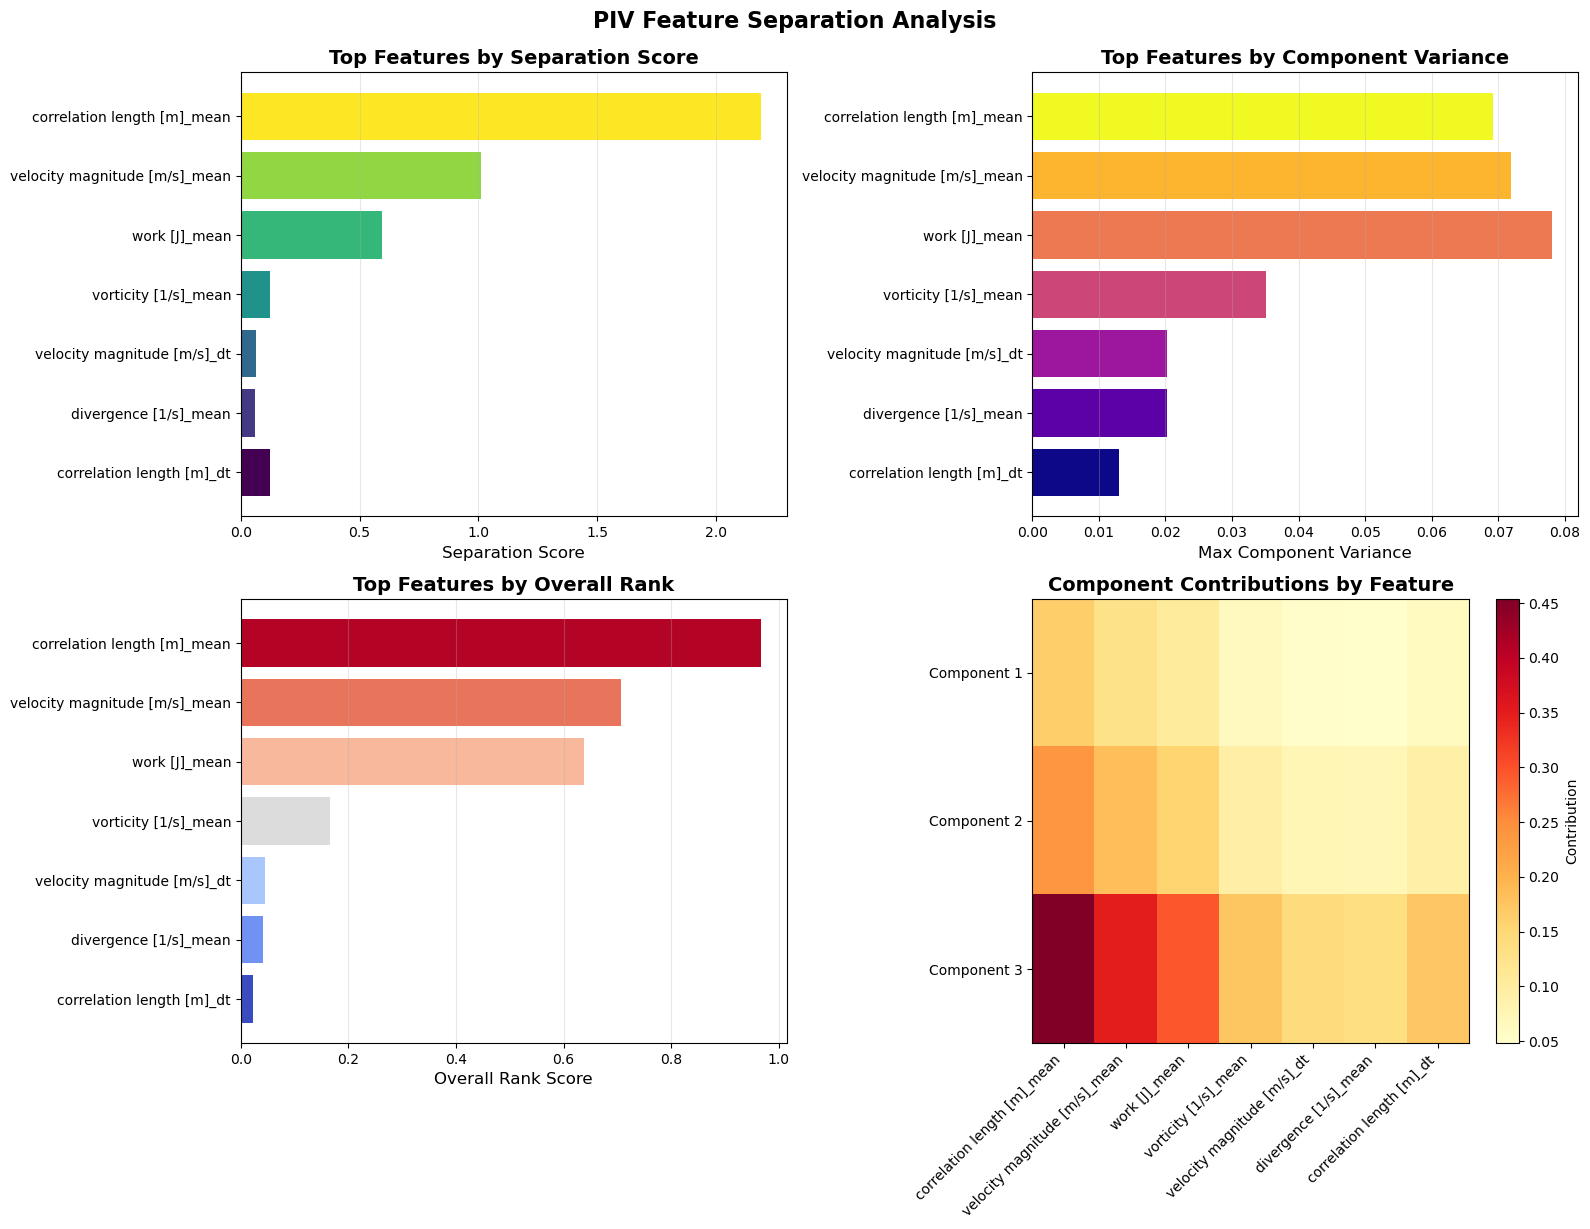


Key Findings:
  • Best separating feature: correlation length [m]_mean
  • Top 3 features: correlation length [m]_mean, velocity magnitude [m/s]_mean, work [J]_mean
  • These features show the strongest differences between motor conditions


In [113]:
# Visualize Feature Separation Rankings

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Separation Score Ranking
ax1 = axes[0, 0]
top_n = 8
top_features = feature_df.head(top_n)
ax1.barh(range(len(top_features)), top_features['Separation_Score'].values[::-1], 
         color=plt.cm.viridis(np.linspace(0, 1, len(top_features))))
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(top_features['Feature'].values[::-1])
ax1.set_xlabel('Separation Score', fontsize=12)
ax1.set_title('Top Features by Separation Score', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Component Variance Ranking
ax2 = axes[0, 1]
ax2.barh(range(len(top_features)), top_features['Max_Component_Variance'].values[::-1],
         color=plt.cm.plasma(np.linspace(0, 1, len(top_features))))
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_features['Feature'].values[::-1])
ax2.set_xlabel('Max Component Variance', fontsize=12)
ax2.set_title('Top Features by Component Variance', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 3. Overall Ranking
ax3 = axes[1, 0]
ax3.barh(range(len(top_features)), top_features['Overall_Rank'].values[::-1],
         color=plt.cm.coolwarm(np.linspace(0, 1, len(top_features))))
ax3.set_yticks(range(len(top_features)))
ax3.set_yticklabels(top_features['Feature'].values[::-1])
ax3.set_xlabel('Overall Rank Score', fontsize=12)
ax3.set_title('Top Features by Overall Rank', fontsize=14, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Component-specific contributions heatmap
ax4 = axes[1, 1]
comp_contrib_matrix = []
for comp_idx in range(n_components):
    comp_contrib = []
    for feat_name in top_features['Feature'].values:
        # Find contribution for this feature in this component
        contrib = next((c for name, c in component_feature_contributions[comp_idx] if name == feat_name), 0)
        comp_contrib.append(contrib)
    comp_contrib_matrix.append(comp_contrib)

comp_contrib_matrix = np.array(comp_contrib_matrix)
im = ax4.imshow(comp_contrib_matrix, cmap='YlOrRd', aspect='auto')
ax4.set_xticks(range(len(top_features)))
ax4.set_xticklabels(top_features['Feature'].values, rotation=45, ha='right')
ax4.set_yticks(range(n_components))
ax4.set_yticklabels([f'Component {i+1}' for i in range(n_components)])
ax4.set_title('Component Contributions by Feature', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax4, label='Contribution')

plt.tight_layout()
plt.suptitle('PIV Feature Separation Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\nKey Findings:")
print(f"  • Best separating feature: {feature_df.iloc[0]['Feature']}")
print(f"  • Top 3 features: {', '.join(feature_df.head(3)['Feature'].values)}")
print(f"  • These features show the strongest differences between motor conditions")

Creating final motor cluster analysis...


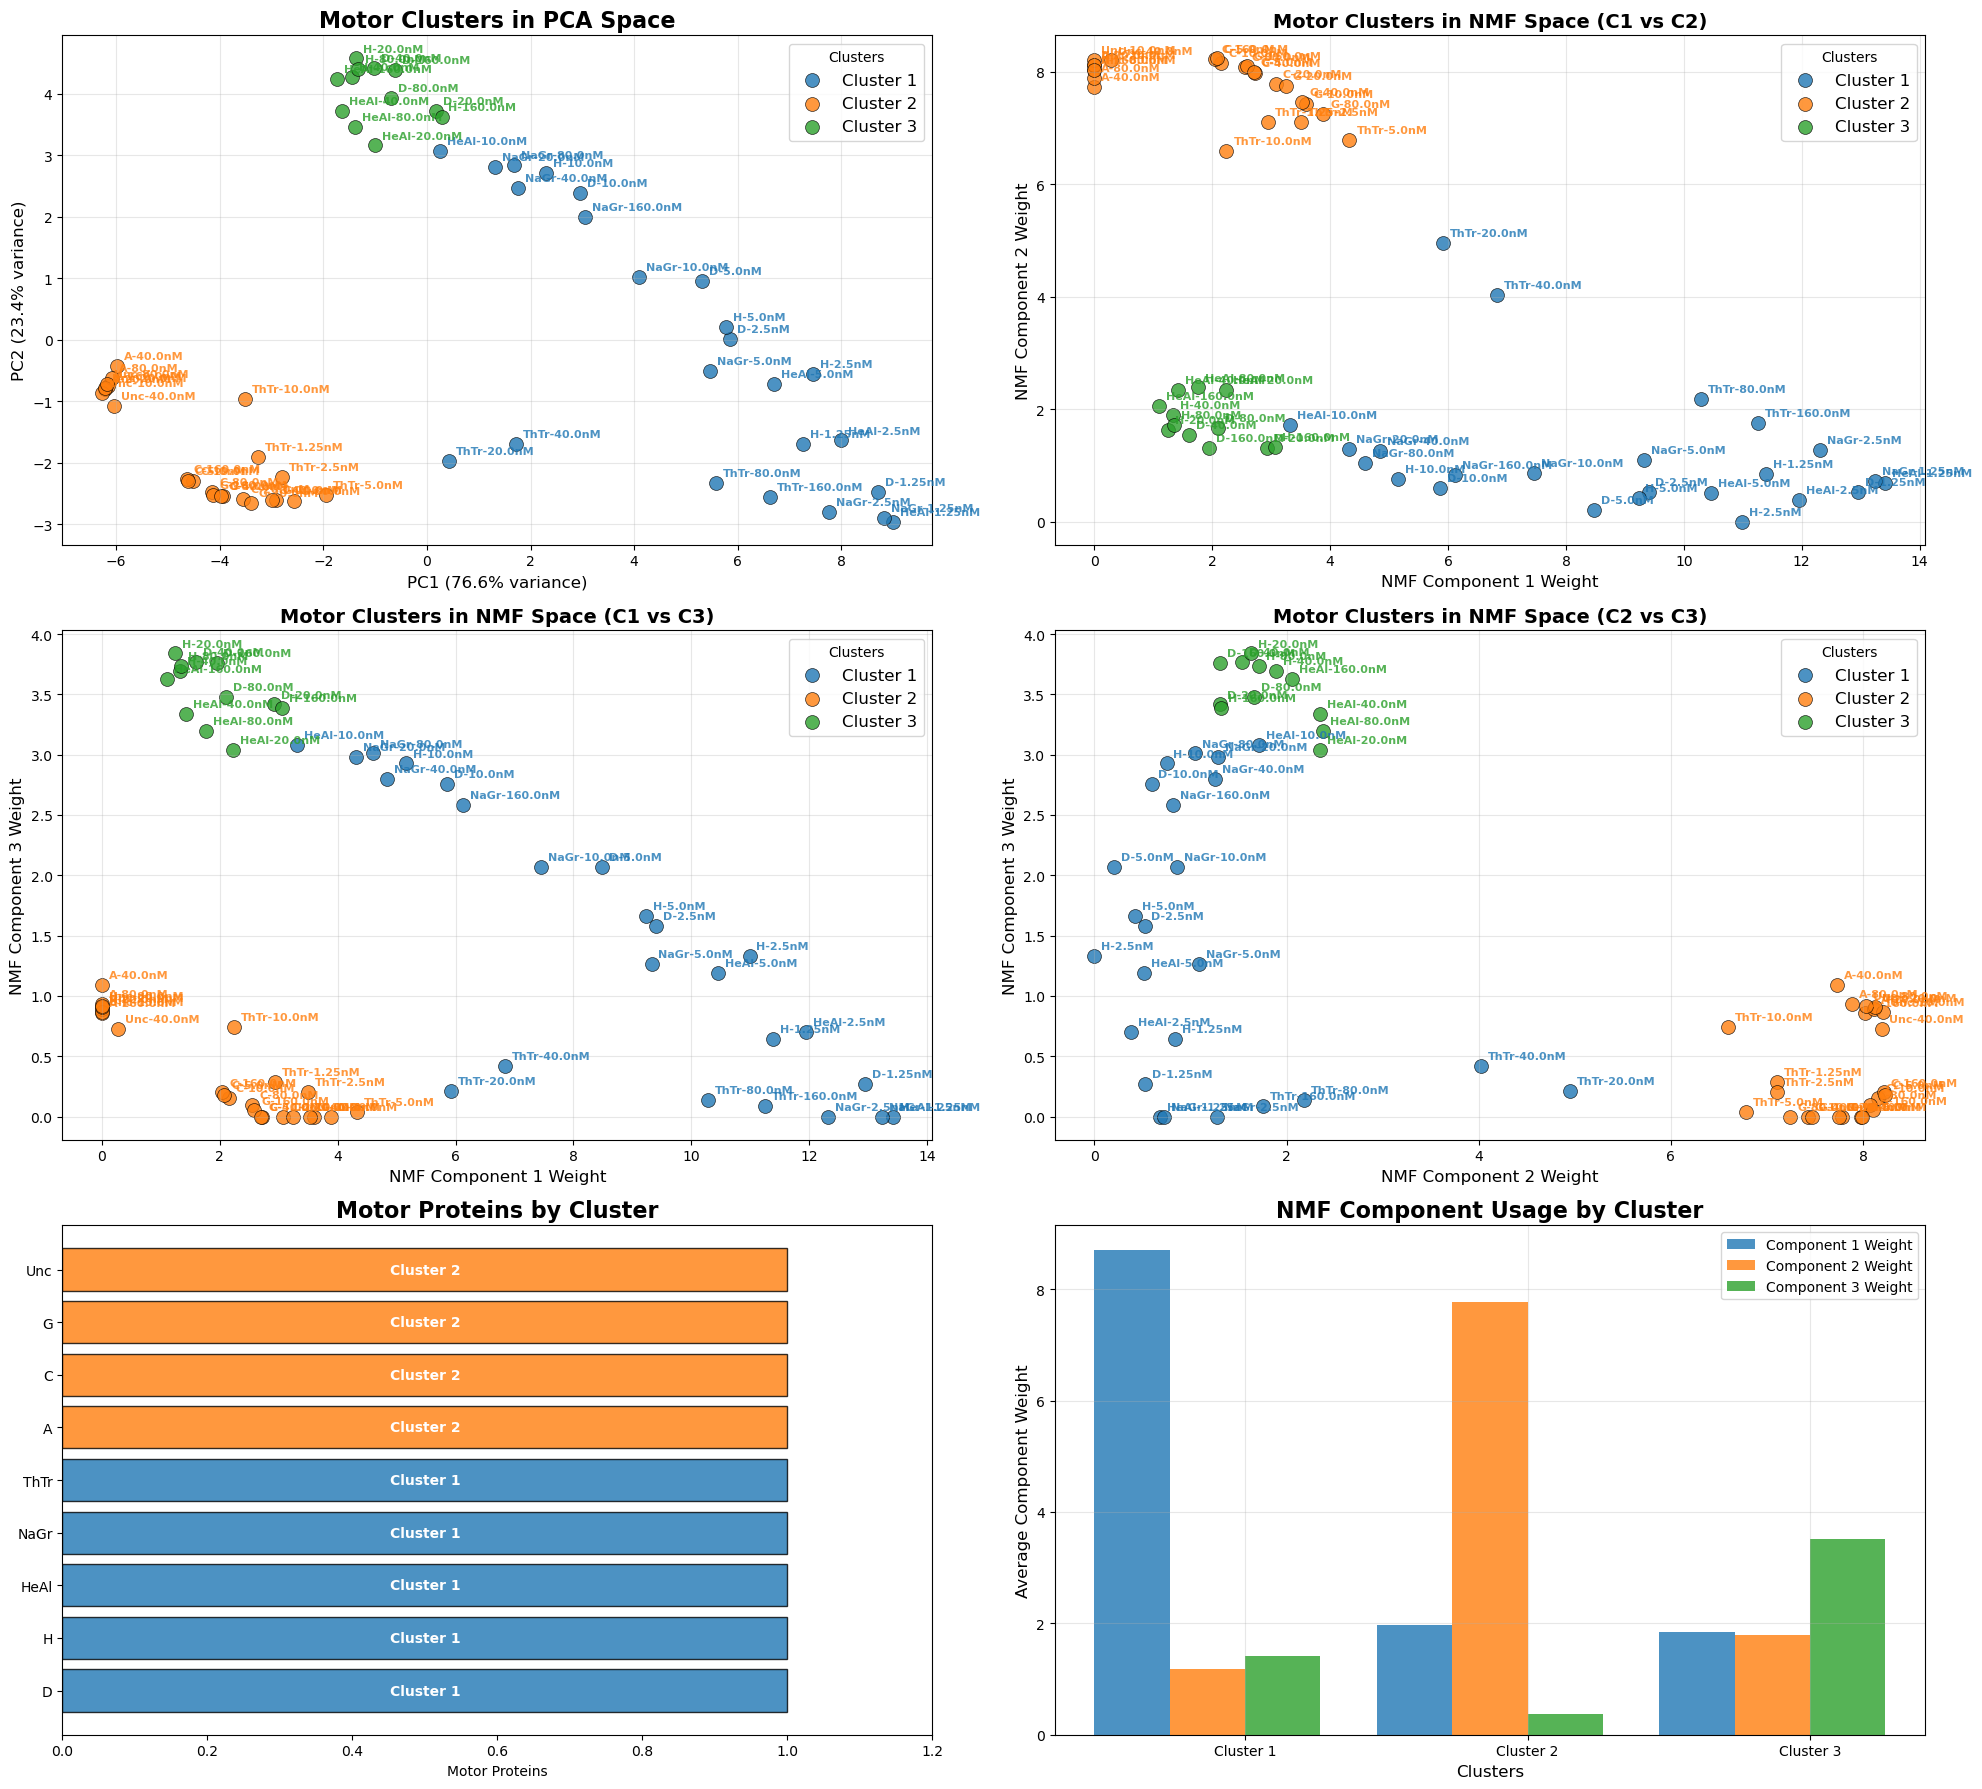

Final behavioral cluster analysis complete!


In [114]:
# Complete the analysis: Create final motor cluster visualization (dynamic component count)
print("Creating final motor cluster analysis...")

import itertools, math
n_components = nmf_results['n_components']
component_names = [f'Component {i+1}' for i in range(n_components)]
cluster_names = [f'Cluster {i+1}' for i in range(n_components)]
base_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
cluster_colors = list(itertools.islice(itertools.cycle(base_colors), n_components))

H_matrix = nmf_results['H'].T  # (conditions × components)

# Prepare axes: PCA plot + all pairwise component scatters + protein bars + usage chart
component_pairs = list(itertools.combinations(range(n_components), 2))
plots_needed = 1 + len(component_pairs) + 2  # PCA + pairs + bar/usage
rows = math.ceil(plots_needed / 2)
fig, axes = plt.subplots(rows, 2, figsize=(20, 6 * rows))
axes = axes.flatten()
ax_idx = 0

# Plot 1: Motor clusters in PCA space
from sklearn.decomposition import PCA
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(H_matrix)
ax1 = axes[ax_idx]; ax_idx += 1
for i in range(n_components):
    component_mask = dominant_components == i
    ax1.scatter(X_pca_2d[component_mask, 0], X_pca_2d[component_mask, 1], 
               c=cluster_colors[i], label=f'{cluster_names[i]}', 
               alpha=0.8, s=100, edgecolors='black', linewidth=0.5)
    
    for j, (x, y) in enumerate(zip(X_pca_2d[component_mask, 0], X_pca_2d[component_mask, 1])):
        condition_idx = np.where(component_mask)[0][j]
        motor_name = condition_summary.iloc[condition_idx]['Condition']
        ax1.annotate(motor_name, (x, y), xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.8, color=cluster_colors[i], fontweight='bold')

ax1.set_title('Motor Clusters in PCA Space', fontsize=16, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax1.legend(title='Clusters', fontsize=12)
ax1.grid(True, alpha=0.3)

# Pairwise component scatter plots
for c1, c2 in component_pairs:
    ax = axes[ax_idx]; ax_idx += 1
    for i in range(n_components):
        component_mask = dominant_components == i
        ax.scatter(H_matrix[component_mask, c1], H_matrix[component_mask, c2], 
                   c=cluster_colors[i], label=f'{cluster_names[i]}', 
                   alpha=0.8, s=100, edgecolors='black', linewidth=0.5)
        
        for j, (x, y) in enumerate(zip(H_matrix[component_mask, c1], H_matrix[component_mask, c2])):
            condition_idx = np.where(component_mask)[0][j]
            motor_name = condition_summary.iloc[condition_idx]['Condition']
            ax.annotate(motor_name, (x, y), xytext=(5, 5), textcoords='offset points',
                        fontsize=8, alpha=0.8, color=cluster_colors[i], fontweight='bold')
    ax.set_title(f'Motor Clusters in NMF Space (C{c1+1} vs C{c2+1})', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'NMF Component {c1+1} Weight', fontsize=12)
    ax.set_ylabel(f'NMF Component {c2+1} Weight', fontsize=12)
    ax.legend(title='Clusters', fontsize=12)
    ax.grid(True, alpha=0.3)

# Plot: Motor proteins by cluster
ax_protein = axes[ax_idx]; ax_idx += 1
protein_clusters = condition_summary.groupby('Protein')['Dominant_Component'].agg(lambda x: x.mode().iloc[0]).reset_index()
protein_clusters.columns = ['Protein', 'Dominant_Component']
component_to_cluster = {comp: cluster_names[i] for i, comp in enumerate(component_names)}
protein_clusters['Cluster'] = protein_clusters['Dominant_Component'].map(component_to_cluster)
cluster_order = cluster_names
protein_clusters['Cluster_Order'] = protein_clusters['Cluster'].map({name: i for i, name in enumerate(cluster_order)})
protein_clusters = protein_clusters.sort_values(['Cluster_Order', 'Protein'])

y_pos = np.arange(len(protein_clusters))
colors = [cluster_colors[cluster_order.index(cluster)] for cluster in protein_clusters['Cluster']]

bars = ax_protein.barh(y_pos, [1]*len(protein_clusters), color=colors, alpha=0.8, edgecolor='black')
ax_protein.set_yticks(y_pos)
ax_protein.set_yticklabels(protein_clusters['Protein'])
ax_protein.set_xlabel('Motor Proteins')
ax_protein.set_title('Motor Proteins by Cluster', fontsize=16, fontweight='bold')
ax_protein.set_xlim(0, 1.2)
for i, (protein, cluster) in enumerate(protein_clusters[['Protein', 'Cluster']].values):
    ax_protein.text(0.5, i, cluster, ha='center', va='center', 
             fontweight='bold', color='white', fontsize=10)

# Plot: NMF component usage by cluster
ax_usage = axes[ax_idx]; ax_idx += 1
component_weight_cols = [col for col in condition_summary.columns if col.startswith('Component_') and col.endswith('_Weight')]
cluster_components = condition_summary.groupby('Dominant_Component')[component_weight_cols].mean()
cluster_components = cluster_components.reindex(component_names)

x = np.arange(len(cluster_components))
width = 0.8 / max(len(component_weight_cols), 1)
for idx, col in enumerate(component_weight_cols):
    ax_usage.bar(x + (idx - len(component_weight_cols)/2) * width, 
                 cluster_components[col], width, 
                 label=col.replace('_', ' '), color=cluster_colors[idx % len(cluster_colors)], alpha=0.8)

ax_usage.set_xlabel('Clusters', fontsize=12)
ax_usage.set_ylabel('Average Component Weight', fontsize=12)
ax_usage.set_title('NMF Component Usage by Cluster', fontsize=16, fontweight='bold')
ax_usage.set_xticks(x)
ax_usage.set_xticklabels(cluster_names)
ax_usage.legend(fontsize=10)
ax_usage.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Final behavioral cluster analysis complete!")


Applying KMeans clustering with silhouette-based k selection (on NMF H matrix)...
Suggested optimal K (by silhouette): 3  (score: 0.661)
Silhouette scores for k in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]: ['0.515', '0.661', '0.619', '0.611', '0.648', '0.626', '0.613', '0.575', '0.535', '0.553']
Using manual K: 5


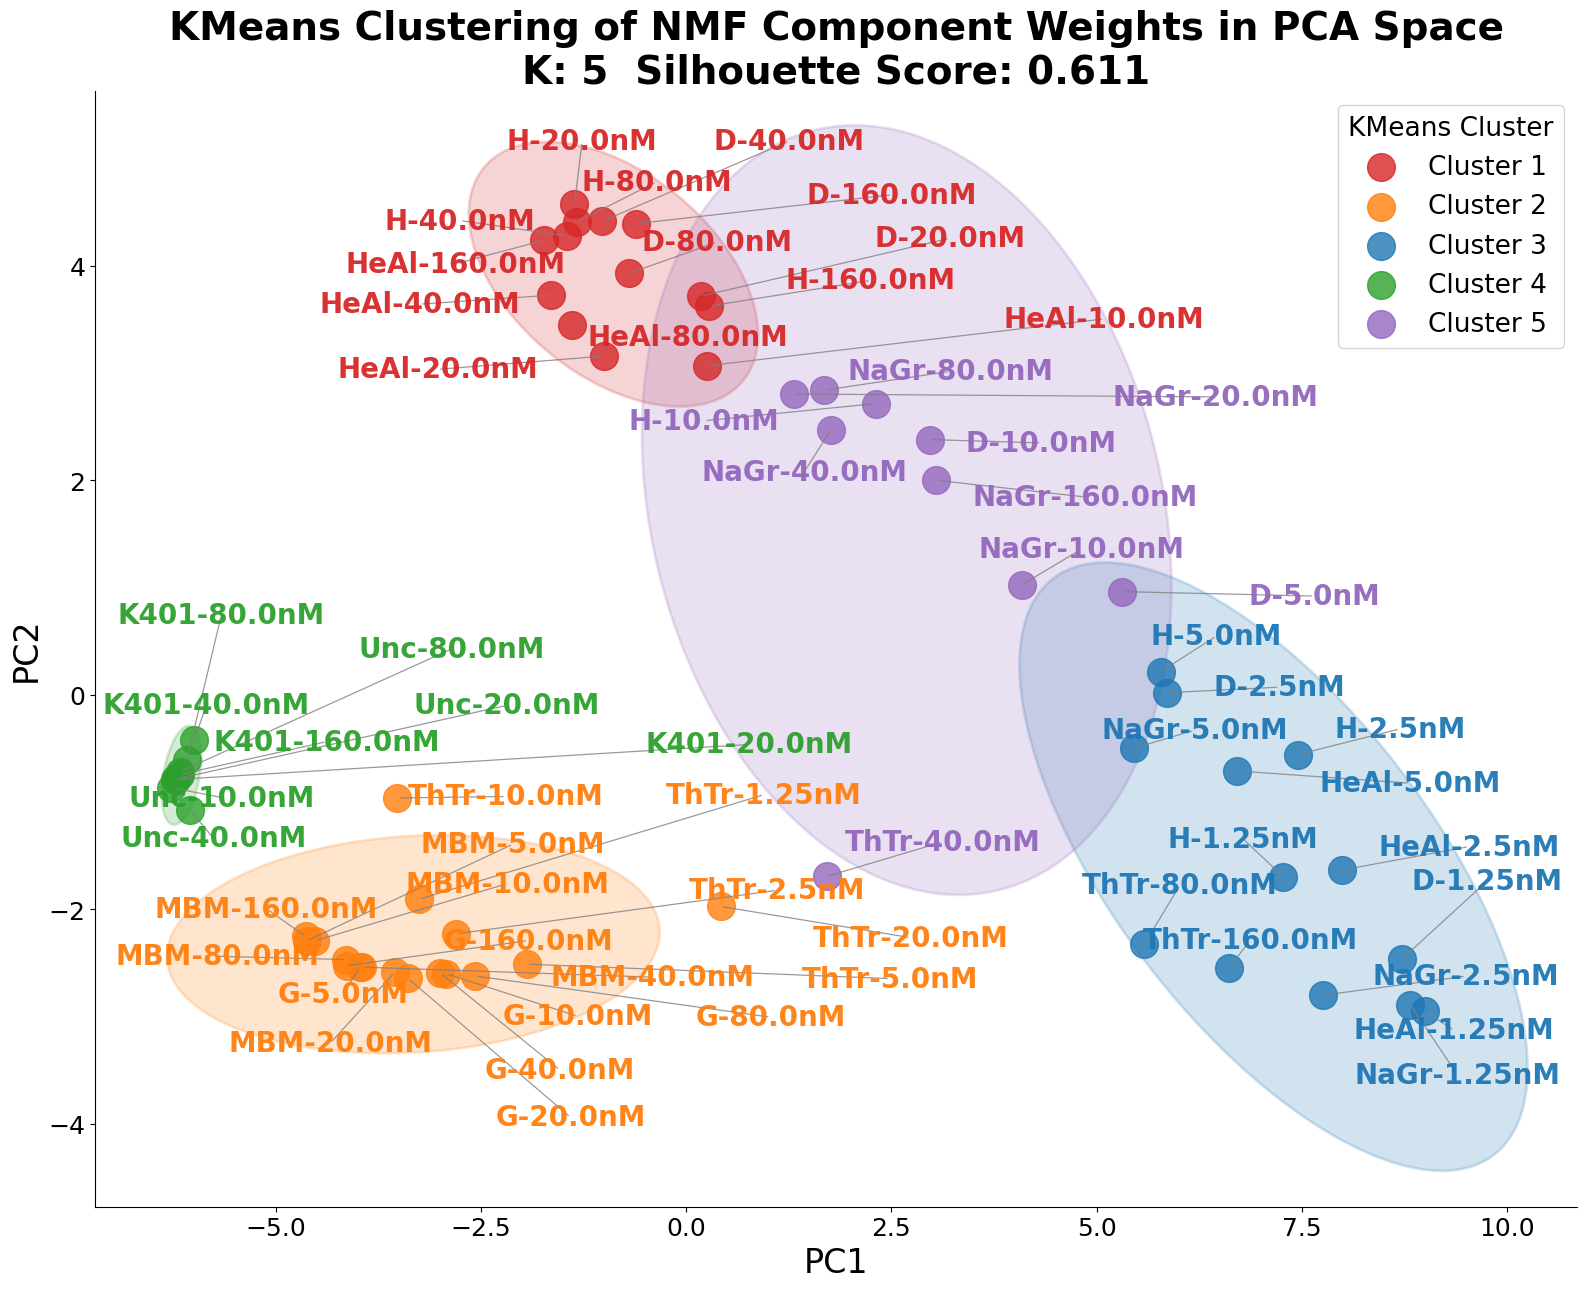

PCA plot with KMeans-based clusters and ellipses complete!


In [115]:
# KMeans clustering with silhouette-based cluster number selection (on NMF H matrix), or manual k selection
print("Applying KMeans clustering with silhouette-based k selection (on NMF H matrix)...")

from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
from adjustText import adjust_text
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib

# --- NAME MAPPING for conditions ---
def rename_motor_condition(cond):
    # If condition starts with "A-" replace with "K401-"
    if cond.startswith('A-'):
        return 'K401-' + cond.split('-', 1)[1]
    # If condition starts with "C-" replace with "MBM-"
    elif cond.startswith('C-'):
        return 'MBM-' + cond.split('-', 1)[1]
    else:
        return cond

# Step 1: Prepare H_matrix (conditions × components)
H_matrix = nmf_results['H'].T

# Step 2: Search for optimal k using silhouette score, or allow user override
k_range = range(2, min(12, H_matrix.shape[0]))  # do not have more clusters than data points
silhouette_avgs = []
kmeans_models = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    cluster_labels = kmeans.fit_predict(H_matrix)
    try:
        sil_avg = silhouette_score(H_matrix, cluster_labels)
    except Exception:
        sil_avg = -1
    silhouette_avgs.append(sil_avg)
    kmeans_models.append(kmeans)

optimal_k_idx = int(np.argmax(silhouette_avgs))
suggested_k = k_range[optimal_k_idx]
suggested_kmeans = kmeans_models[optimal_k_idx]
suggested_labels = suggested_kmeans.labels_
suggested_silhouette = silhouette_avgs[optimal_k_idx]

print(f"Suggested optimal K (by silhouette): {suggested_k}  (score: {suggested_silhouette:.3f})")
print("Silhouette scores for k in {}: {}".format(list(k_range), [f'{v:.3f}' for v in silhouette_avgs]))

# --------- ALLOW USER TO PICK k MANUALLY ---------
# Set to None to use silhouette suggestion, or override with your chosen value (e.g. 3)
manual_k_choice = 5  # <--- Set to an integer (from k_range) to override

if manual_k_choice is not None and manual_k_choice in k_range:
    print(f"Using manual K: {manual_k_choice}")
    k_index = list(k_range).index(manual_k_choice)
    chosen_k = manual_k_choice
    best_kmeans = kmeans_models[k_index]
    final_labels = best_kmeans.labels_
    best_silhouette = silhouette_avgs[k_index]
else:
    print("Using silhouette-based optimal K.")
    chosen_k = suggested_k
    best_kmeans = suggested_kmeans
    final_labels = suggested_labels
    best_silhouette = suggested_silhouette


# --------- SELECT CLUSTER COLORS YOURSELF ---------
# Get default matplotlib colors for reference (but you can use whatever you want)
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
cluster_names = [f'Cluster {i+1}' for i in range(chosen_k)]


# --- MANUALLY ASSIGN CLUSTER INDEX TO YOUR DESIRED COLOR!
# --- Do NOT change the indices (0 ... chosen_k-1), just change the strings on the right
# Use a comprehensive color palette that supports many clusters
import matplotlib.colors as mcolors

# Create an extended color palette with many distinct colors
# Use tab10 (10 colors), Set3 (12 colors), and tab20 (20 colors) for up to 42 distinct colors
tab10_colors = [mcolors.rgb2hex(plt.cm.tab10(i/10.0)[:3]) for i in range(10)]
set3_colors = [mcolors.rgb2hex(plt.cm.Set3(i/12.0)[:3]) for i in range(12)]
tab20_colors = [mcolors.rgb2hex(plt.cm.tab20(i/20.0)[:3]) for i in range(20)]
# Combine into one extended palette
extended_colors = tab10_colors + set3_colors + tab20_colors

# Create color map for all clusters (cycles through extended palette if needed)
user_cluster_color_map = {
    i: extended_colors[i % len(extended_colors)] for i in range(chosen_k)
}

# Alternative: Use named colors if you prefer (uncomment to use instead):
named_colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:green', 'tab:purple', 
                'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan',
                'crimson', 'darkorange', 'royalblue', 'limegreen', 'mediumpurple',
                'saddlebrown', 'hotpink', 'dimgray', 'darkolivegreen', 'darkcyan']
user_cluster_color_map = {i: named_colors[i % len(named_colors)] for i in range(chosen_k)}

# --- END: your cluster-to-color assignment ---

# Now, propagate these to a cluster_colors list, in the index order for plotting, legend, etc
cluster_colors = []
for i in range(chosen_k):
    if i in user_cluster_color_map:
        cluster_colors.append(user_cluster_color_map[i])
    else:
        cluster_colors.append(default_colors[i % len(default_colors)])

# Font sizes
big_fontsize = 24
med_fontsize = 18
label_fontsize = 16
title_fontsize = 28
legend_fontsize = 19
annotate_fontsize = 20

# Step 3: PCA projection for plotting
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(H_matrix)

# Step 4: Plotting
fig, ax = plt.subplots(figsize=(16, 13))

# Plot clusters and 2D confidence ellipses
for cluster_idx in range(chosen_k):
    cluster_mask = (final_labels == cluster_idx)
    cluster_points = X_pca_2d[cluster_mask]
    color = cluster_colors[cluster_idx]
    
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], 
               c=color, label=cluster_names[cluster_idx], 
               s=400, alpha=0.8, linewidth=1, zorder=2)
    
    if len(cluster_points) > 2:
        mean_x = cluster_points[:, 0].mean()
        mean_y = cluster_points[:, 1].mean()
        cov_matrix = np.cov(cluster_points[:, 0], cluster_points[:, 1])
        lambda_, v = np.linalg.eigh(cov_matrix)
        lambda_ = np.sqrt(lambda_)
        scale = 2.447  # 95% ellipse
        width = lambda_[0] * scale * 2
        height = lambda_[1] * scale * 2
        angle = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
        ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle,
                          facecolor=color, alpha=0.2, 
                          edgecolor=color, linewidth=2, zorder=1)
        ax.add_patch(ellipse)

# Annotate each condition (motor) in the plot
texts = []
for idx in range(len(X_pca_2d)):
    x, y = X_pca_2d[idx, 0], X_pca_2d[idx, 1]
    cluster_id = final_labels[idx]
    color = cluster_colors[cluster_id]
    original_motor_name = condition_summary.iloc[idx]['Condition']
    motor_name = rename_motor_condition(original_motor_name)
    txt = ax.text(x, y, motor_name,
                  fontsize=annotate_fontsize, alpha=0.95, color=color,
                  fontweight='bold', zorder=5)
    texts.append(txt)

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.9, alpha=0.8),
    expand_points=(1.2, 1.2),
    expand_text=(1.05, 1.05),
    force_points=0.5,
    force_text=0.5,
    only_move={'points': 'y', 'text': 'xy'}
)

ax.set_xlabel('PC1', fontsize=big_fontsize)
ax.set_ylabel('PC2', fontsize=big_fontsize)
ax.set_title(f'KMeans Clustering of NMF Component Weights in PCA Space\nK: {chosen_k}  Silhouette Score: {best_silhouette:.3f}', 
             fontsize=title_fontsize, fontweight='bold')
ax.legend(title='KMeans Cluster', fontsize=legend_fontsize, title_fontsize=legend_fontsize, loc='best')
ax.tick_params(axis='both', which='major', labelsize=med_fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../../../../Downloads/pcafig6.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print("PCA plot with KMeans-based clusters and ellipses complete!")


['ThTr-160nM', 'ThTr-80nM', 'ThTr-40nM', 'ThTr-20nM', 'ThTr-10nM', 'ThTr-5nM', 'ThTr-2nM', 'ThTr-1nM', 'C-160nM', 'C-80nM', 'C-40nM', 'C-20nM', 'C-10nM', 'C-5nM', 'C-2.5nM', 'C-2nM', 'C-1.25nM', 'C-1nM', 'G-160nM', 'G-80nM', 'G-40nM', 'G-20nM', 'G-10nM', 'G-5nM', 'G-2.5nM', 'G-2nM', 'G-1.25nM', 'G-1nM', 'A-160nM', 'A-80nM', 'A-40nM', 'A-20nM', 'HeAl-160nM', 'HeAl-80nM', 'HeAl-40nM', 'HeAl-20nM', 'HeAl-10nM', 'HeAl-5nM', 'HeAl-2nM', 'HeAl-1nM', 'NaGr-160nM', 'NaGr-80nM', 'NaGr-40nM', 'NaGr-20nM', 'NaGr-10nM', 'NaGr-5nM', 'NaGr-2nM', 'NaGr-1nM', 'Unc-160.0nM', 'Unc-160nM', 'Unc-80nM', 'Unc-40nM', 'Unc-20nM', 'Unc-10nM', 'Unc-5.0nM', 'Unc-5nM', 'Unc-2.5nM', 'Unc-2nM', 'Unc-1.25nM', 'Unc-1nM']


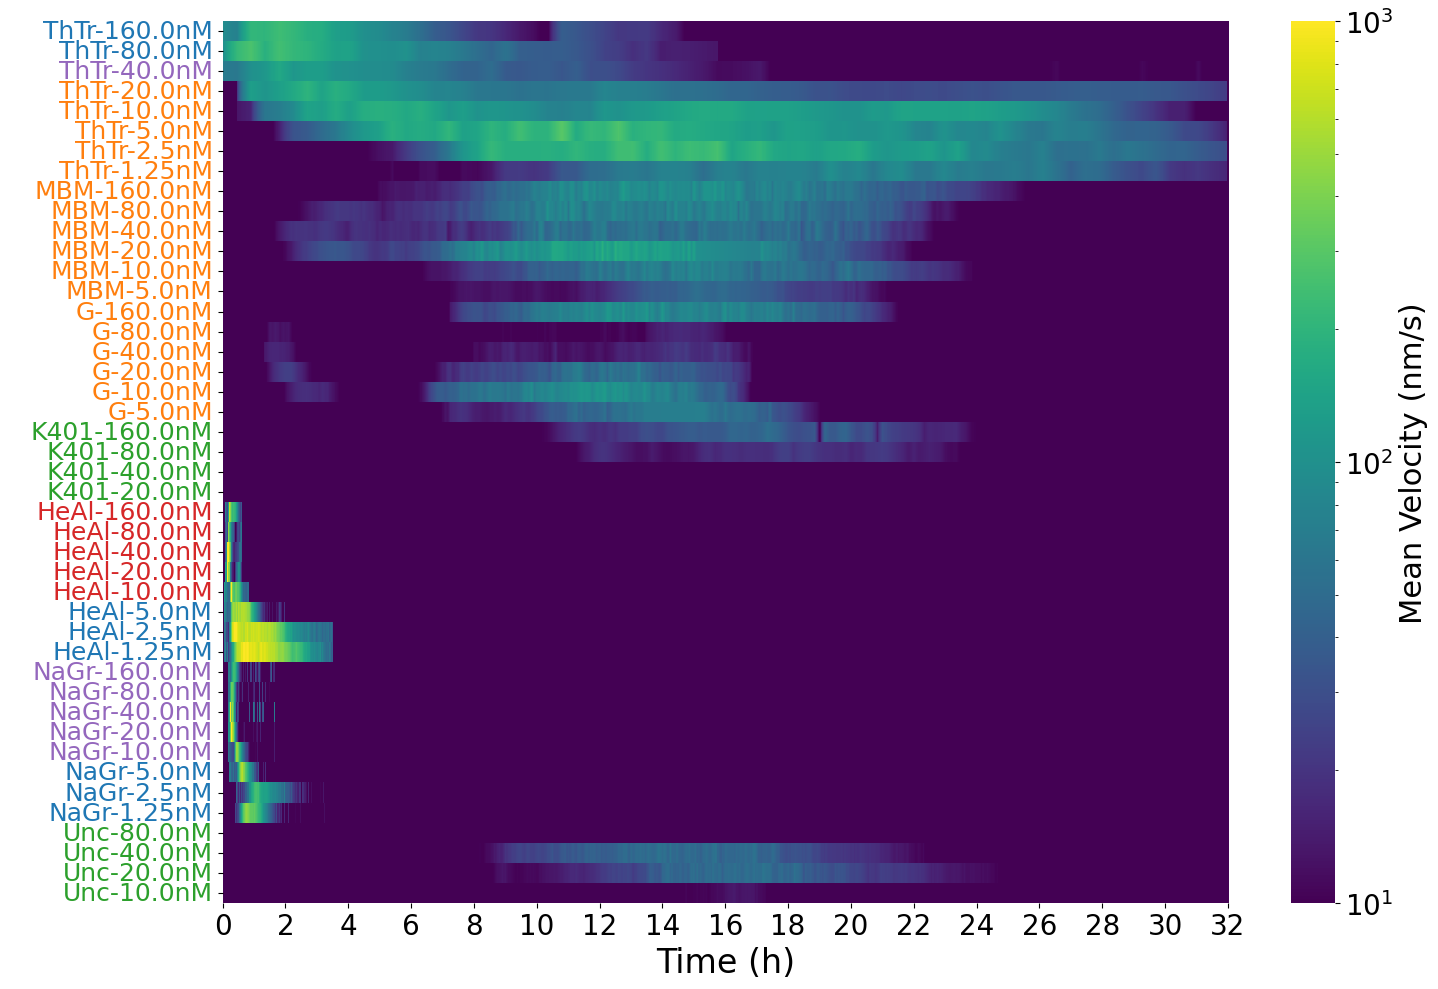

In [116]:
def plot_velocity_heatmap(
    df,
    selection_dict=None,  # allow None to select all
    selected_time_limit_s=None,
    resample_sec=60,
    log_scale=True,
    vmin=None,
    vmax=None,
    figsize=(15, 10),
    cmap='viridis',
    save_path=None,
    save_format='auto',  # <- new argument
    skip_ticks_h=2,
    colorbar_label="Mean Velocity (nm/s)",  # CHANGED UNITS HERE
    xlabel='Time (h)',
    ylabel=' ',
    title="Velocity Over Time Matrix",
    dpi=300,
    xtick_fontsize=20,
    ytick_fontsize=18,
    xlabel_fontsize=24,
    ylabel_fontsize=12,
    title_fontsize=14,
    colorbar_fontsize=20,
    colorbar_labelsize=22,
    tight_layout=True,
    zero_replacement=1e-13,  # changed default zero replacement for log scale
    verbose=True,
    all_proteins_dnas=False,   # NEW: set to True to ignore selection_dict and do all conditions
    condition_summary=None,     # NEW: DataFrame with 'Condition' column for cluster mapping
    final_labels=None,         # NEW: array of cluster assignments (same length as condition_summary)
    user_cluster_color_map=None,  # NEW: dict mapping cluster index to color (e.g., {0: 'tab:red', 1: 'tab:orange', ...})
):
    """
    Plot a velocity-over-time heatmap with flexible protein-DNA selection and log/linear options.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe, must include 'time (s)', 'condition', and 'velocity magnitude [m/s]_mean' columns.
    selection_dict : dict or None
        Dictionary where keys are protein names (str), and values are list of DNA concentrations (float).
        Order of conditions in heatmap will follow this dictionary. If None and all_proteins_dnas is False, will plot all proteins/dnas found in the data.
    all_proteins_dnas : bool
        If True, selection_dict is ignored and all unique conditions in the data are shown in label order.
    selected_time_limit_s : float or None, optional
        Maximum time in seconds to show on x-axis. None for all.
    resample_sec : int, optional
        Resample to this interval in seconds (default=60).
    log_scale : bool, optional
        Use log scale color for heatmap (default True).
    vmin, vmax : float or None, optional
        Minimum and maximum for color scale (required for log).
    figsize : tuple, optional
        Figure size.
    cmap : str, optional
        Color map for heatmap.
    save_path : str or None, optional
        If given, saves to this path.
    save_format : str, optional
        One of 'svg', 'png', or 'auto' (infer from extension). Default 'auto'.
    skip_ticks_h : int, optional
        Spacing between x-ticks in hours.
    verbose : bool, optional
        If True, will print diagnostic info when no columns match, and suggest valid input.
    Remaining arguments are passed for styling.
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.colors
    import os

    # Helper functions
    def get_dna_conc_from_condition(condition_name):
        try:
            dna_part = condition_name.split('-')[1].replace('nM', '')
            return float(dna_part)
        except (IndexError, ValueError):
            return np.nan

    def get_protein_from_condition(condition_name):
        return condition_name.split('-')[0]

    def rename_motor_condition(cond):
        """Rename motor conditions to match PCA plot naming convention."""
        # If condition starts with "A-" replace with "K401-"
        if cond.startswith('A-'):
            return 'K401-' + cond.split('-', 1)[1]
        # If condition starts with "C-" replace with "MBM-"
        elif cond.startswith('C-'):
            return 'MBM-' + cond.split('-', 1)[1]
        else:
            return cond

    # Decide what to plot: all (default if selection_dict=None or all_proteins_dnas True), or from selection_dict
    if all_proteins_dnas or (selection_dict is None):
        # Use all available in dataframe, in sorted order
        all_conditions = sorted(df['condition'].dropna().unique().tolist())
        col_order = all_conditions
        used_selection = "ALL"
    else:
        # Build ordered list of columns to plot, following selection_dict order
        col_order = []
        for protein, dna_list in selection_dict.items():
            for dna in dna_list:
                # Try both floating and plain integer name matches
                try:
                    dfloat = float(dna)
                except Exception:
                    dfloat = dna
                col_name_float = f"{protein}-{float(dna)}nM"
                col_name_int = f"{protein}-{int(float(dna))}nM"
                col_order.append(col_name_float)
                if col_name_int != col_name_float:
                    col_order.append(col_name_int)
        # preserve only unique
        col_order = list(dict.fromkeys(col_order))  # keep order, remove dups
        used_selection = repr(selection_dict)

    # Create velocity matrix: rows = time, columns = (all possible conditions)
    velocity_matrix = df.pivot_table(
        index='time (s)',
        columns='condition',
        values='velocity magnitude [m/s]_mean',
        aggfunc='mean'
    )
    # Convert from m/s to nm/s everywhere
    velocity_matrix = velocity_matrix * 1e9

    # Resample to uniform time grid as requested
    min_time = velocity_matrix.index.min()
    max_time = velocity_matrix.index.max()
    uniform_time_grid = np.arange(min_time, max_time + resample_sec, resample_sec)
    velocity_matrix = velocity_matrix.reindex(uniform_time_grid)

    # Apply time limit if desired
    if selected_time_limit_s is not None:
        velocity_matrix = velocity_matrix[velocity_matrix.index <= selected_time_limit_s]

    # Interpolate missing values (only between valid for each motor)
    velocity_matrix_interp = velocity_matrix.copy()
    for col in velocity_matrix_interp.columns:
        s = velocity_matrix_interp[col]
        first_valid = s.first_valid_index()
        last_valid = s.last_valid_index()
        if first_valid is not None and last_valid is not None:
            s_interp = s.loc[first_valid:last_valid].interpolate(method='linear', limit_direction='both')
            s_new = pd.Series(np.nan, index=s.index)
            s_new.loc[first_valid:last_valid] = s_interp
            velocity_matrix_interp[col] = s_new

    # Fill remaining NaN with 0 for plotting
    velocity_matrix_interp_clean = velocity_matrix_interp.fillna(0)

    # Figure out which columns to display (intersection of col_order and actual columns)
    requested_cols = list(dict.fromkeys(col_order))
    available_cols = list(velocity_matrix_interp_clean.columns)
    columns_present = [col for col in requested_cols if col in available_cols]
    if all_proteins_dnas or (selection_dict is None):
        # for all, just do all columns actually present in data with non-all-NaN
        columns_present = [c for c in available_cols if not (velocity_matrix_interp_clean[c] == 0).all()]
        velocity_matrix_interp_clean_sorted = velocity_matrix_interp_clean[columns_present]
    else:
        velocity_matrix_interp_clean_sorted = velocity_matrix_interp_clean[columns_present]

    # Diagnostics
    if not columns_present:
        if verbose:
            print("ERROR: No columns matching the selection_dict found in dataframe.")
            print("Requested column names (from your selection_dict):")
            print(requested_cols)
            print("Available column names in dataframe (truncated to 20 shown):")
            print(available_cols[:20], "..." if len(available_cols) > 20 else "")
            # Try to suggest the closest match for each protein-dna combination requested.
            from difflib import get_close_matches
            print("\nSUGGESTION:")
            if not (all_proteins_dnas or selection_dict is None):
                for protein, dna_list in selection_dict.items():
                    for dna in dna_list:
                        candidates = [c for c in available_cols if c.startswith(f"{protein}-")]
                        if candidates:
                            matches = get_close_matches(f"{protein}-{dna}nM", candidates, n=2)
                            print(f"  {protein}-{dna}nM: Closest in data: {matches if matches else candidates[:2]}")
                        else:
                            print(f"  {protein}-{dna}nM: No '{protein}-' prefix found at all in dataframe.")
            print("\nTIP: Check that your selection_dict and data column names match in nM formatting (1.25 vs 1.2, integer vs float) and spelling.")
        raise ValueError("No columns matching the selection_dict found in dataframe. See above output for diagnostics.")
    else:
        if verbose and not (all_proteins_dnas or selection_dict is None):
            missing = [col for col in requested_cols if col not in columns_present]
            if missing:
                print("WARNING: The following requested conditions were not found and will be skipped:")
                print(missing)
        elif verbose and (all_proteins_dnas or selection_dict is None):
            print(f"Plotting ALL proteins and DNA nM concentrations, total: {len(columns_present)} conditions.")

    plt.figure(figsize=figsize)

    # Log/linear prepare
    if log_scale:
        # Check vmin/vmax
        if vmin is None or vmax is None:
            vmin = vmin or velocity_matrix_interp_clean_sorted.replace(0, np.nan).min().min()
            vmax = vmax or velocity_matrix_interp_clean_sorted.max().max()
            if vmin is None or vmin <= 0:
                vmin = 1e-5  # fallback, in nm/s
            if vmax is None or vmax <= 0:
                vmax = 1e2  # fallback, in nm/s
        # Replace zeros for log plotting
        velocity_plot = velocity_matrix_interp_clean_sorted.replace(0, zero_replacement)
        norm = matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)
        heatmap_kws = dict(
            cmap=cmap,
            cbar_kws={'label': colorbar_label },
            xticklabels=False,
            yticklabels=True,
            norm=norm,
            vmin=None,
            vmax=None
        )
    else:
        velocity_plot = velocity_matrix_interp_clean_sorted
        norm = None
        # vmin and vmax should be passed for linear scale if set
        cbar_kws = {'label': colorbar_label}
        heatmap_kws = dict(
            cmap=cmap,
            cbar_kws=cbar_kws,
            xticklabels=False,
            yticklabels=True
        )
        if vmin is not None:
            heatmap_kws['vmin'] = vmin
        if vmax is not None:
            heatmap_kws['vmax'] = vmax

    ax = sns.heatmap(
        velocity_plot.T,
        **heatmap_kws
    )

    # Set colorbar properties
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=colorbar_fontsize)
    cbar.set_label(colorbar_label, size=colorbar_labelsize)

    # Set x-axis ticks at every skip_ticks_h hours (e.g. 0, 2, 4,...)
    times_sec = velocity_matrix_interp_clean_sorted.index.values.astype(float)
    if selected_time_limit_s is not None:
        times_sec = times_sec[times_sec <= selected_time_limit_s]
        max_time_hours = selected_time_limit_s / 3600
    else:
        max_time_hours = times_sec[-1] / 3600

    tick_hours = np.arange(0, max_time_hours + skip_ticks_h, skip_ticks_h)
    tick_times_sec = tick_hours * 3600

    tick_positions = []
    available_times = velocity_matrix_interp_clean_sorted.index.values.astype(float)
    for target_time in tick_times_sec:
        idx = np.abs(available_times - target_time).argmin()
        if available_times[idx] <= available_times[-1]:
            tick_positions.append(idx)
    # Set x-ticks at indices
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"{int(h)}" for h in tick_hours[:len(tick_positions)]], fontsize=xtick_fontsize)
    
    # Build condition-to-color mapping if cluster information is provided
    condition_color_map = {}
    if condition_summary is not None and final_labels is not None and user_cluster_color_map is not None:
        # Create mapping from condition names to cluster colors
        for idx in range(len(condition_summary)):
            condition_name = str(condition_summary.iloc[idx]['Condition'])
            cluster_idx = final_labels[idx]
            if cluster_idx in user_cluster_color_map:
                condition_color_map[condition_name] = user_cluster_color_map[cluster_idx]
    
    # Set y-axis labels with cluster colors if available
    yticklabels = ax.get_yticklabels()
    yticklabel_texts = [label.get_text() for label in yticklabels]
    
    for label, text in zip(yticklabels, yticklabel_texts):
        label.set_fontsize(ytick_fontsize)
        # Rename condition name to match PCA plot convention
        renamed_text = rename_motor_condition(text)
        # Update label text with renamed version
        label.set_text(renamed_text)
        # Apply cluster color if mapping exists (use original text for matching)
        if condition_color_map and text in condition_color_map:
            label.set_color(condition_color_map[text])
        elif condition_color_map:
            # Try to match with variations (e.g., handle float vs int formatting)
            # Check if any key in condition_color_map matches this condition
            matched = False
            for cond_key, color in condition_color_map.items():
                # Try exact match, or match after normalizing
                if text == cond_key or text.replace('.0nM', 'nM') == cond_key.replace('.0nM', 'nM'):
                    label.set_color(color)
                    matched = True
                    break
            # If still no match, try matching by protein-DNA pattern
            if not matched:
                for cond_key, color in condition_color_map.items():
                    # Extract protein and DNA from both
                    try:
                        text_protein = text.split('-')[0]
                        text_dna = text.split('-')[1].replace('nM', '')
                        key_protein = cond_key.split('-')[0]
                        key_dna = cond_key.split('-')[1].replace('nM', '')
                        if text_protein == key_protein and abs(float(text_dna) - float(key_dna)) < 0.01:
                            label.set_color(color)
                            break
                    except:
                        pass
    
    ax.set_yticklabels(yticklabels)

    plt.xlabel(xlabel, fontsize=xlabel_fontsize)
    plt.ylabel(ylabel, fontsize=ylabel_fontsize)
    # plt.title(title, fontsize=title_fontsize)
    if tight_layout:
        plt.tight_layout()

    if save_path is not None:
        save_dir = os.path.dirname(save_path)
        os.makedirs(save_dir, exist_ok=True)
        # Determine format
        _format = None
        if save_format == 'auto':
            ext = os.path.splitext(save_path)[1].lower().lstrip('.')
            if ext in ['svg', 'png']:
                _format = ext
            else:
                _format = 'png'
        else:
            _format = save_format.lower()
        plt.savefig(save_path, format=_format, dpi=dpi)
    plt.show()

# Example usages:

# (1) Using previous style: select subset (as before)
plot_velocity_heatmap(
    df,
    selection_dict={
        # 'AcSu':   [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        # 'AcSu2':  [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        # 'AdPa':   [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        # 'D':      [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        # 'DiPu':   [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        # 'G':      [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        # 'H':      [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        'ThTr':   [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        'C':      [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        'G':      [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        'A':      [160,80, 40, 20,],
        'HeAl':   [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        # 'Kif5':   [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        'NaGr':   [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        # 'TiLa':   [160,80, 40, 20, 10, 5, 2.5, 1.25,],
        'Unc':    [160,80, 40, 20, 10, 5, 2.5, 1.25,],
    },
    all_proteins_dnas=False,
    selected_time_limit_s=60*60*32,
    log_scale=True,
    vmin=10,
    vmax=1000,
    save_path="../../../../Downloads/dnatitratasdionsss.svg",
    condition_summary=condition_summary,  # Pass cluster information
    final_labels=final_labels,
    user_cluster_color_map=user_cluster_color_map
)


Creating PCA plot with NMF-derived component clusters (no silhouette bars)...
NMF dominant component labeling complete!
Overall Silhouette Score (NMF clusters): 0.566


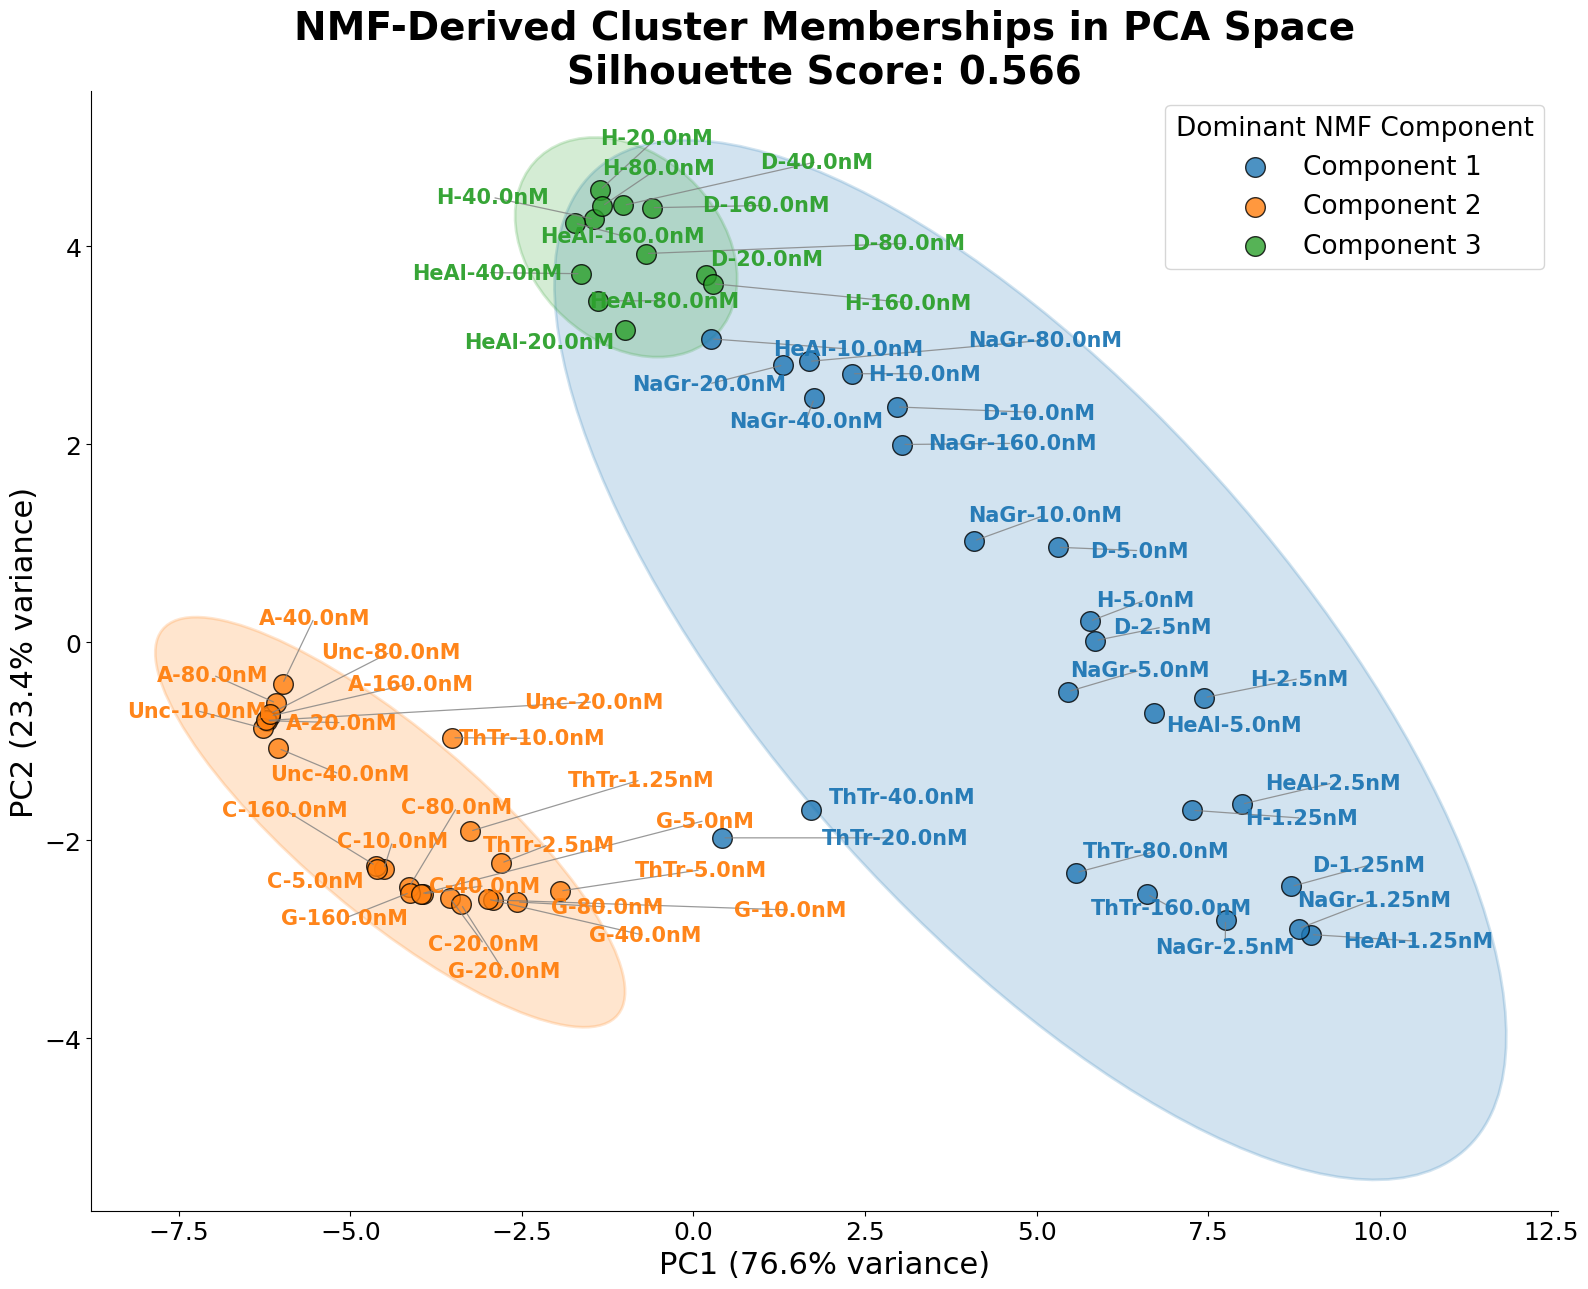

PCA plot with NMF-derived component clusters and ellipses complete!


In [117]:
# PCA plot using NMF-derived dominant component clusters (no silhouette bars overlaid)
print("Creating PCA plot with NMF-derived component clusters (no silhouette bars)...")

from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
from adjustText import adjust_text
import numpy as np

# Also import matplotlib default color cycler
import matplotlib

# Step 1: Use dominant NMF component (argmax per row of H^T) as cluster assignment
H_matrix = nmf_results['H'].T  # shape: (conditions × components)
nmf_clusters = np.argmax(H_matrix, axis=1)  # shape: (num_conditions,)

# Step 2 (optional): Calculate silhouette score for NMF clusters
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(H_matrix, nmf_clusters)

print("NMF dominant component labeling complete!")
print(f"Overall Silhouette Score (NMF clusters): {silhouette_avg:.3f}")

# Step 3: Create PCA projection
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(H_matrix)

# Step 4: Create plot with clusters and ellipses (no silhouette bars)
fig, ax = plt.subplots(figsize=(16, 13))  # Larger figure

# Use the default matplotlib tab10 cycler: orange, green, blue for clusters 1/2/3
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
n_components = H_matrix.shape[1]
cluster_colors = default_colors[:n_components]
cluster_names = [f'Component {c+1}' for c in range(n_components)]

# For larger fonts
big_fontsize = 22
med_fontsize = 18
label_fontsize = 16
title_fontsize = 28
legend_fontsize = 19
annotate_fontsize = 15

# Plot clusters with ellipses (like tutorial)
for comp_idx in range(n_components):
    cluster_mask = nmf_clusters == comp_idx
    cluster_points = X_pca_2d[cluster_mask]
    color = cluster_colors[comp_idx]
    
    # Plot data points
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], 
               c=color, label=f'{cluster_names[comp_idx]}', 
               s=200, alpha=0.8, edgecolors='black', linewidth=1, zorder=2)
    
    # Draw cluster boundary (ellipse) using confidence ellipse
    if len(cluster_points) > 2:
        centroid_pc1 = cluster_points[:, 0].mean()
        centroid_pc2 = cluster_points[:, 1].mean()
        mean_x, mean_y = centroid_pc1, centroid_pc2
        cov_matrix = np.cov(cluster_points[:, 0], cluster_points[:, 1])
        lambda_, v = np.linalg.eigh(cov_matrix)
        lambda_ = np.sqrt(lambda_)
        scale = 2.447  # For 95% confidence (2 degrees of freedom)
        width = lambda_[0] * scale * 2
        height = lambda_[1] * scale * 2
        angle = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
        ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle,
                          facecolor=color, alpha=0.2, 
                          edgecolor=color, linewidth=2, zorder=1)
        ax.add_patch(ellipse)

# Overlay motor labels at each point with collision avoidance and leader lines
texts = []
for idx in range(len(X_pca_2d)):
    x, y = X_pca_2d[idx, 0], X_pca_2d[idx, 1]
    cluster_id = nmf_clusters[idx]
    color = cluster_colors[cluster_id]
    motor_name = condition_summary.iloc[idx]['Condition']
    txt = ax.text(x, y, motor_name,
                  fontsize=annotate_fontsize, alpha=0.95, color=color,
                  fontweight='bold', zorder=5)
    texts.append(txt)

# Nudge labels to avoid overlap; draw short straight connectors back to points
adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.9, alpha=0.8),
    expand_points=(1.2, 1.2),
    expand_text=(1.05, 1.05),
    force_points=0.5,
    force_text=0.5,
    only_move={'points': 'y', 'text': 'xy'}
)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=big_fontsize)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=big_fontsize)
ax.set_title(f'NMF-Derived Cluster Memberships in PCA Space\nSilhouette Score: {silhouette_avg:.3f}', 
             fontsize=title_fontsize, fontweight='bold')
ax.legend(title='Dominant NMF Component', fontsize=legend_fontsize, title_fontsize=legend_fontsize, loc='best')

# Increase tick label font size
ax.tick_params(axis='both', which='major', labelsize=med_fontsize)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../../../../Downloads/motor_clustersds_pca2_nmfclusters.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print("PCA plot with NMF-derived component clusters and ellipses complete!")
